<a href="https://colab.research.google.com/github/trang1981/ELAPS/blob/main/Notebooks/VIB_cutoff90ngay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LOAD DỮ LIỆU

XỬ LÝ FILE TARGET

In [ ]:
# ==========================================================
# CREATE TARGET FILE FOR LANDMARK EXPERIMENT
# ==========================================================

import os
import pandas as pd
import numpy as np
from google.colab import drive

# ==========================================================
# MOUNT GOOGLE DRIVE
# ==========================================================
drive.mount("/content/drive", force_remount=True)

# ==========================================================
# PATH
# ==========================================================
BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "6.Data_Card.xlsx"
)

OUTPUT_FILE = os.path.join(
    BASE_DIR,
    "target_raw_processed.csv"
)

print("Input:", INPUT_FILE)
print("Output:", OUTPUT_FILE)

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(INPUT_FILE)

# ==========================================================
# READ DATA
# ==========================================================
card = pd.read_excel(INPUT_FILE)

card.columns = (
    card.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nColumns")
print(card.columns.tolist())

# ==========================================================
# REQUIRED COLUMNS
# ==========================================================
required = [
    "CUSTOMER_NUMBER",
    "COUNT_CREDITCARD",
    "MONTH"
]

missing = [
    c for c in required
    if c not in card.columns
]

if len(missing) > 0:
    raise ValueError(
        f"Missing columns: {missing}"
    )

# ==========================================================
# CLEAN
# ==========================================================
card = card[
    [
        "CUSTOMER_NUMBER",
        "COUNT_CREDITCARD",
        "MONTH"
    ]
].copy()

card = card.dropna(
    subset=["CUSTOMER_NUMBER"]
)

card["CUSTOMER_NUMBER"] = (
    card["CUSTOMER_NUMBER"]
    .astype(str)
    .str.strip()
)

card["COUNT_CREDITCARD"] = (
    pd.to_numeric(
        card["COUNT_CREDITCARD"],
        errors="coerce"
    )
    .fillna(0)
)

card["MONTH"] = pd.to_datetime(
    card["MONTH"],
    errors="coerce"
)

card = card.dropna(
    subset=["MONTH"]
)

# ==========================================================
# TOTAL CARD
# ==========================================================
summary = (
    card
    .groupby(
        "CUSTOMER_NUMBER",
        as_index=False
    )
    .agg(
        TOTAL_CARD=(
            "COUNT_CREDITCARD",
            "sum"
        ),
        FIRST_OBS_MONTH=(
            "MONTH",
            "min"
        ),
        LAST_OBS_MONTH=(
            "MONTH",
            "max"
        )
    )
)

# ==========================================================
# TARGET
# ==========================================================
summary["TARGET"] = (
    summary["TOTAL_CARD"] > 0
).astype(int)

# ==========================================================
# FIRST CARD MONTH
# ==========================================================
first_card = (
    card[
        card["COUNT_CREDITCARD"] > 0
    ]
    .groupby(
        "CUSTOMER_NUMBER",
        as_index=False
    )
    .agg(
        FIRST_CARD_MONTH=(
            "MONTH",
            "min"
        )
    )
)

summary = summary.merge(
    first_card,
    on="CUSTOMER_NUMBER",
    how="left"
)

# ==========================================================
# TARGET MONTH
# ==========================================================
summary["TARGET_MONTH"] = summary["FIRST_CARD_MONTH"]

summary.loc[
    summary["TARGET"] == 0,
    "TARGET_MONTH"
] = summary.loc[
    summary["TARGET"] == 0,
    "LAST_OBS_MONTH"
]

# ==========================================================
# SAVE
# ==========================================================
summary.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

# ==========================================================
# REPORT
# ==========================================================
print("\n====================================")
print("RESULT")
print("====================================")

print(summary.head())

print("\nShape:", summary.shape)

print("\nTarget distribution")
print(
    summary["TARGET"]
    .value_counts()
)

print("\nPositive rate:",
      round(
          summary["TARGET"].mean()*100,
          2
      ),
      "%")

print("\nSaved:")
print(OUTPUT_FILE)

Mounted at /content/drive
Input: /content/drive/MyDrive/Fintect/6.Data_Card.xlsx
Output: /content/drive/MyDrive/Fintect/target_raw_processed.csv

Columns
['MONTH', 'COUNT_CREDITCARD', 'COUNT_DEBITCARD', 'CUSTOMER_NUMBER']

RESULT
  CUSTOMER_NUMBER  TOTAL_CARD FIRST_OBS_MONTH LAST_OBS_MONTH  TARGET  \
0               0           0      2019-09-30     2019-12-31       0   
1          100009           0      2019-08-31     2019-12-31       0   
2          100018           0      2019-11-30     2019-12-31       0   
3          100019           7      2019-06-30     2019-12-31       1   
4          100026           9      2019-04-30     2019-12-31       1   

  FIRST_CARD_MONTH TARGET_MONTH  
0              NaT   2019-12-31  
1              NaT   2019-12-31  
2              NaT   2019-12-31  
3       2019-06-30   2019-06-30  
4       2019-04-30   2019-04-30  

Shape: (150459, 7)

Target distribution
TARGET
0    108085
1     42374
Name: count, dtype: int64

Positive rate: 28.16 %

Saved:
/co

In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/Fintect"

print(os.listdir(BASE_DIR))

['1.Data_Customer.csv', '5.Data_Lending.xlsx', '6.Data_Card.xlsx', '2.Data_MyVIB_Transaction.csv', '4.Data_Deposit.csv', 'target_raw_processed.csv']


4️⃣ Nối CUSTOMER với TARGET

In [ ]:
import os
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/Fintect"

TARGET_RAW_FILE = os.path.join(
    BASE_DIR,
    "target_raw_processed.csv"
)

CUSTOMER_FILE = os.path.join(
    BASE_DIR,
    "1.Data_Customer.csv"
)

OUTPUT_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_90d.csv"
)

# Đọc dữ liệu target
target = pd.read_csv(
    TARGET_RAW_FILE,
    low_memory=False
)

# Đọc dữ liệu customer
customer = pd.read_csv(
    CUSTOMER_FILE,
    low_memory=False
)

# Chuẩn hóa tên cột
target.columns = (
    target.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

customer.columns = (
    customer.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

# Kiểm tra cột cần thiết
required_customer_columns = [
    "CUSTOMER_NUMBER",
    "CLIENT_CREATE_DATE"
]

missing = [
    col for col in required_customer_columns
    if col not in customer.columns
]

if missing:
    raise ValueError(
        f"Thiếu cột: {missing}\n"
        f"Các cột hiện có: {customer.columns.tolist()}"
    )

# Chọn các cột cần dùng
customer = customer[
    [
        "CUSTOMER_NUMBER",
        "CLIENT_CREATE_DATE"
    ]
].copy()

# Làm sạch mã khách hàng
customer = customer.dropna(
    subset=["CUSTOMER_NUMBER"]
)

customer["CUSTOMER_NUMBER"] = (
    customer["CUSTOMER_NUMBER"]
    .astype(str)
    .str.strip()
)

target["CUSTOMER_NUMBER"] = (
    target["CUSTOMER_NUMBER"]
    .astype(str)
    .str.strip()
)

# Chuyển ngày
customer["CLIENT_CREATE_DATE"] = pd.to_datetime(
    customer["CLIENT_CREATE_DATE"],
    errors="coerce"
)

customer = customer.dropna(
    subset=["CLIENT_CREATE_DATE"]
)

# Một khách có nhiều dòng thì lấy ngày tạo sớm nhất
customer = (
    customer
    .groupby(
        "CUSTOMER_NUMBER",
        as_index=False
    )
    .agg(
        RELATIONSHIP_START_DATE=(
            "CLIENT_CREATE_DATE",
            "min"
        )
    )
)

# Chuyển các cột ngày trong target
date_columns = [
    "FIRST_CARD_MONTH",
    "FIRST_OBS_MONTH",
    "LAST_OBS_MONTH",
    "TARGET_MONTH"
]

for col in date_columns:
    if col in target.columns:
        target[col] = pd.to_datetime(
            target[col],
            errors="coerce"
        )

# Ghép dữ liệu
landmark = target.merge(
    customer,
    on="CUSTOMER_NUMBER",
    how="inner",
    validate="one_to_one"
)

print("Số khách trước khi ghép:", len(target))
print("Số khách sau khi ghép:", len(landmark))

# Tạo landmark 90 ngày
landmark["LANDMARK_DATE"] = (
    landmark["RELATIONSHIP_START_DATE"]
    + pd.Timedelta(days=90)
)

# Kiểm tra khách có đủ thời gian quan sát tới ngày 90
landmark["HAS_90D_FOLLOWUP"] = (
    landmark["LAST_OBS_MONTH"]
    >= landmark["LANDMARK_DATE"]
)

print(
    "Khách không đủ 90 ngày quan sát:",
    (~landmark["HAS_90D_FOLLOWUP"]).sum()
)

landmark = landmark[
    landmark["HAS_90D_FOLLOWUP"]
].copy()

# Khách mở thẻ trước hoặc đúng ngày 90
landmark["EARLY_CARD_90D"] = (
    landmark["FIRST_CARD_MONTH"].notna()
    &
    (
        landmark["FIRST_CARD_MONTH"]
        <= landmark["LANDMARK_DATE"]
    )
)

print(
    "Khách mở thẻ trong 90 ngày đầu:",
    landmark["EARLY_CARD_90D"].sum()
)

# Loại khách đã mở thẻ trong 90 ngày đầu
landmark_eligible = landmark[
    ~landmark["EARLY_CARD_90D"]
].copy()

# TARGET mới:
# 1 = mở thẻ sau ngày 90
# 0 = không mở thẻ
landmark_eligible["TARGET_90D"] = (
    landmark_eligible["FIRST_CARD_MONTH"].notna()
    &
    (
        landmark_eligible["FIRST_CARD_MONTH"]
        > landmark_eligible["LANDMARK_DATE"]
    )
).astype(int)

# Toàn bộ feature phải cắt tại landmark
landmark_eligible["FEATURE_CUTOFF_DATE"] = (
    landmark_eligible["LANDMARK_DATE"]
)

# Chọn cột đầu ra
target_landmark_90d = landmark_eligible[
    [
        "CUSTOMER_NUMBER",
        "RELATIONSHIP_START_DATE",
        "LANDMARK_DATE",
        "FEATURE_CUTOFF_DATE",
        "FIRST_CARD_MONTH",
        "LAST_OBS_MONTH",
        "TARGET_90D"
    ]
].copy()

# Kiểm tra leakage logic
invalid_positive = (
    (target_landmark_90d["TARGET_90D"] == 1)
    &
    (
        target_landmark_90d["FIRST_CARD_MONTH"]
        <= target_landmark_90d["FEATURE_CUTOFF_DATE"]
    )
).sum()

if invalid_positive > 0:
    raise ValueError(
        f"Có {invalid_positive} positive bị sai thời gian."
    )

# Lưu file
target_landmark_90d.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

# Thống kê
print("\n" + "=" * 60)
print("LANDMARK 90-DAY TARGET")
print("=" * 60)

print(target_landmark_90d.head())

print("\nShape:", target_landmark_90d.shape)

print("\nPhân bố TARGET_90D:")
print(
    target_landmark_90d["TARGET_90D"]
    .value_counts()
    .sort_index()
)

print(
    "\nPositive rate:",
    round(
        target_landmark_90d["TARGET_90D"].mean() * 100,
        2
    ),
    "%"
)

print("\nSaved:")
print(OUTPUT_FILE)

Số khách trước khi ghép: 150459
Số khách sau khi ghép: 150459
Khách không đủ 90 ngày quan sát: 39800
Khách mở thẻ trong 90 ngày đầu: 28077

LANDMARK 90-DAY TARGET
  CUSTOMER_NUMBER RELATIONSHIP_START_DATE LANDMARK_DATE FEATURE_CUTOFF_DATE  \
0               0              2019-09-16    2019-12-15          2019-12-15   
1          100009              2019-08-23    2019-11-21          2019-11-21   
2          100018              2019-10-02    2019-12-31          2019-12-31   
5          100028              2019-01-05    2019-04-05          2019-04-05   
6          100029              2019-09-27    2019-12-26          2019-12-26   

  FIRST_CARD_MONTH LAST_OBS_MONTH  TARGET_90D  
0              NaT     2019-12-31           0  
1              NaT     2019-12-31           0  
2              NaT     2019-12-31           0  
5              NaT     2019-12-31           0  
6              NaT     2019-12-31           0  

Shape: (82582, 7)

Phân bố TARGET_90D:
TARGET_90D
0    77089
1     5493
N

6️⃣ Nối TRANSACTION

In [ ]:
# ============================================================
# LANDMARK 90-DAY TRANSACTION FILTERING
#
# Mục tiêu:
# - Giữ toàn bộ khách hàng trong target_landmark_90d.csv
# - Chỉ giữ giao dịch từ ngày bắt đầu quan hệ
#   đến trước FEATURE_CUTOFF_DATE (ngày thứ 90)
# - Không làm mất khách hàng không có giao dịch hợp lệ
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

# File master Landmark 90 ngày
MASTER_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_90d.csv"
)

# File giao dịch gốc
TRANSACTION_FILE = os.path.join(
    BASE_DIR,
    "2.Data_MyVIB_Transaction.csv"
)

# Thư mục lưu kết quả
OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "landmark_90d_outputs"
)

# File giao dịch sau khi lọc 90 ngày
OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "step3_transaction_first_90d.csv"
)

# File kiểm tra theo khách hàng
CUSTOMER_CHECK_FILE = os.path.join(
    OUTPUT_DIR,
    "step3_transaction_first_90d_customer_check.csv"
)

# File thống kê
SUMMARY_FILE = os.path.join(
    OUTPUT_DIR,
    "step3_transaction_first_90d_summary.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 3. COLUMN CONFIGURATION
# ============================================================

ID_COL = "CUSTOMER_NUMBER"

TARGET_COL = "TARGET_90D"

START_DATE_COL = "RELATIONSHIP_START_DATE"

CUTOFF_COL = "FEATURE_CUTOFF_DATE"

TRANS_DATE_COL = "TRANS_DATE"


# ============================================================
# 4. CHECK FILES
# ============================================================

for file_path in [
    MASTER_FILE,
    TRANSACTION_FILE
]:
    if not Path(file_path).exists():
        raise FileNotFoundError(
            f"Không tìm thấy file:\n{file_path}"
        )

print("=" * 70)
print("INPUT FILES")
print("=" * 70)

print("MASTER_FILE:")
print(MASTER_FILE)

print("\nTRANSACTION_FILE:")
print(TRANSACTION_FILE)

print("\nOUTPUT_DIR:")
print(OUTPUT_DIR)


# ============================================================
# 5. LOAD LANDMARK MASTER
# ============================================================

master = pd.read_csv(
    MASTER_FILE,
    low_memory=False
)

master.columns = (
    master.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

required_master_cols = [
    ID_COL,
    TARGET_COL,
    START_DATE_COL,
    CUTOFF_COL
]

missing_master_cols = [
    col for col in required_master_cols
    if col not in master.columns
]

if missing_master_cols:
    raise ValueError(
        f"File master thiếu các cột: "
        f"{missing_master_cols}\n"
        f"Các cột hiện có:\n"
        f"{master.columns.tolist()}"
    )


# ============================================================
# 6. STANDARDIZE MASTER DATA
# ============================================================

master[ID_COL] = (
    master[ID_COL]
    .astype(str)
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

master[START_DATE_COL] = pd.to_datetime(
    master[START_DATE_COL],
    errors="coerce"
)

master[CUTOFF_COL] = pd.to_datetime(
    master[CUTOFF_COL],
    errors="coerce"
)

master[TARGET_COL] = pd.to_numeric(
    master[TARGET_COL],
    errors="coerce"
)

# Kiểm tra target
invalid_target = master[
    ~master[TARGET_COL].isin([0, 1])
]

if not invalid_target.empty:
    raise ValueError(
        f"Có {len(invalid_target):,} khách hàng "
        f"có {TARGET_COL} không hợp lệ."
    )

master[TARGET_COL] = (
    master[TARGET_COL]
    .astype(int)
)


# ============================================================
# 7. CHECK DUPLICATE CUSTOMERS
# ============================================================

duplicate_customers = (
    master[ID_COL]
    .duplicated()
    .sum()
)

print("\nDuplicate customers in master:",
      duplicate_customers)

if duplicate_customers > 0:

    duplicate_file = os.path.join(
        OUTPUT_DIR,
        "duplicate_master_customers.csv"
    )

    master.loc[
        master[ID_COL].duplicated(
            keep=False
        )
    ].to_csv(
        duplicate_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        "CUSTOMER_NUMBER bị trùng trong "
        "target_landmark_90d.csv."
    )


# ============================================================
# 8. CHECK LANDMARK DATES
# ============================================================

invalid_dates = master[
    master[START_DATE_COL].isna()
    | master[CUTOFF_COL].isna()
    | (
        master[CUTOFF_COL]
        <= master[START_DATE_COL]
    )
]

print("Customers with invalid dates:",
      len(invalid_dates))

if not invalid_dates.empty:

    invalid_dates_file = os.path.join(
        OUTPUT_DIR,
        "invalid_landmark_dates.csv"
    )

    invalid_dates.to_csv(
        invalid_dates_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        "Có khách hàng thiếu hoặc sai "
        "RELATIONSHIP_START_DATE / "
        "FEATURE_CUTOFF_DATE."
    )


# ============================================================
# 9. CHECK CUTOFF APPROXIMATELY 90 DAYS
# ============================================================

master["LANDMARK_DAYS_CHECK"] = (
    master[CUTOFF_COL]
    - master[START_DATE_COL]
).dt.days

print("\nLandmark days distribution:")
print(
    master["LANDMARK_DAYS_CHECK"]
    .value_counts()
    .sort_index()
    .head(20)
)

invalid_90d = master[
    master["LANDMARK_DAYS_CHECK"] != 90
]

if not invalid_90d.empty:
    print(
        "\nCẢNH BÁO:",
        len(invalid_90d),
        "khách hàng không có landmark đúng 90 ngày."
    )


# ============================================================
# 10. LOAD TRANSACTION DATA
# ============================================================

trans = pd.read_csv(
    TRANSACTION_FILE,
    low_memory=False
)

trans.columns = (
    trans.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

required_trans_cols = [
    ID_COL,
    TRANS_DATE_COL
]

missing_trans_cols = [
    col for col in required_trans_cols
    if col not in trans.columns
]

if missing_trans_cols:
    raise ValueError(
        f"File transaction thiếu cột: "
        f"{missing_trans_cols}\n"
        f"Các cột hiện có:\n"
        f"{trans.columns.tolist()}"
    )


# ============================================================
# 11. STANDARDIZE TRANSACTION DATA
# ============================================================

trans[ID_COL] = (
    trans[ID_COL]
    .astype(str)
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

trans[TRANS_DATE_COL] = pd.to_datetime(
    trans[TRANS_DATE_COL],
    errors="coerce"
)

print("\n" + "=" * 70)
print("TRANSACTION DATA")
print("=" * 70)

print("Rows:", f"{len(trans):,}")
print("Customers:", f"{trans[ID_COL].nunique():,}")
print(
    "Missing TRANS_DATE:",
    f"{trans[TRANS_DATE_COL].isna().sum():,}"
)


# ============================================================
# 12. HANDLE OVERLAPPING COLUMNS
# ============================================================

overlapping_cols = [
    col for col in trans.columns
    if col in master.columns
    and col != ID_COL
]

if overlapping_cols:
    print(
        "\nCác cột bị trùng giữa master "
        "và transaction:"
    )
    print(overlapping_cols)

    # Giữ cột giao dịch từ trans,
    # loại cột trùng khỏi master trước merge
    master_for_merge = master.drop(
        columns=overlapping_cols
    ).copy()

else:
    master_for_merge = master.copy()


# ============================================================
# 13. LEFT JOIN
#
# Giữ toàn bộ khách hàng trong master,
# kể cả khách không có giao dịch.
# ============================================================

df = master_for_merge.merge(
    trans,
    on=ID_COL,
    how="left",
    validate="one_to_many"
)

expected_customers = (
    master_for_merge[ID_COL]
    .nunique()
)

print("\n" + "=" * 70)
print("BEFORE FILTERING")
print("=" * 70)

print("Rows:", f"{len(df):,}")
print(
    "Customers after merge:",
    f"{df[ID_COL].nunique():,}"
)
print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Positive customers:",
    df.loc[
        df[TARGET_COL] == 1,
        ID_COL
    ].nunique()
)

print(
    "Negative customers:",
    df.loc[
        df[TARGET_COL] == 0,
        ID_COL
    ].nunique()
)


# ============================================================
# 14. FILTER TRANSACTIONS IN FIRST 90 DAYS
#
# Giữ:
# 1. Khách không có giao dịch: TRANS_DATE là NaT
#
# 2. Giao dịch thỏa:
#    RELATIONSHIP_START_DATE <= TRANS_DATE
#    và
#    TRANS_DATE < FEATURE_CUTOFF_DATE
#
# Không dùng giao dịch:
# - trước ngày bắt đầu quan hệ;
# - tại hoặc sau ngày thứ 90.
# ============================================================

valid_transaction_mask = (
    df[TRANS_DATE_COL].isna()
    |
    (
        df[TRANS_DATE_COL].notna()
        & df[START_DATE_COL].notna()
        & df[CUTOFF_COL].notna()
        & (
            df[TRANS_DATE_COL]
            >= df[START_DATE_COL]
        )
        & (
            df[TRANS_DATE_COL]
            < df[CUTOFF_COL]
        )
    )
)

df_filtered = df.loc[
    valid_transaction_mask
].copy()


# ============================================================
# 15. FIND CUSTOMERS LOST AFTER FILTERING
#
# Một khách có giao dịch, nhưng tất cả giao dịch:
# - trước ngày tạo khách hàng; hoặc
# - sau ngày thứ 90
#
# sẽ tạm biến mất sau filter.
# Cần thêm lại khách với transaction trống.
# ============================================================

customers_before = set(
    master_for_merge[ID_COL].unique()
)

customers_after_raw_filter = set(
    df_filtered[ID_COL].unique()
)

lost_customers = (
    customers_before
    - customers_after_raw_filter
)

print("\n" + "=" * 70)
print("AFTER RAW FILTERING")
print("=" * 70)

print("Rows:", f"{len(df_filtered):,}")
print(
    "Customers after raw filter:",
    f"{df_filtered[ID_COL].nunique():,}"
)
print(
    "Customers temporarily lost:",
    f"{len(lost_customers):,}"
)


# ============================================================
# 16. RESTORE LOST CUSTOMERS
# ============================================================

if lost_customers:

    missing_rows = master_for_merge[
        master_for_merge[ID_COL].isin(
            lost_customers
        )
    ].copy()

    transaction_only_cols = [
        col for col in trans.columns
        if col != ID_COL
    ]

    for col in transaction_only_cols:
        if col not in missing_rows.columns:
            missing_rows[col] = pd.NA

    # Đưa đúng thứ tự cột
    missing_rows = missing_rows[
        df_filtered.columns
    ]

    df_filtered = pd.concat(
        [
            df_filtered,
            missing_rows
        ],
        ignore_index=True
    )


# ============================================================
# 17. FINAL CUSTOMER CONSISTENCY CHECK
# ============================================================

final_customers = (
    df_filtered[ID_COL]
    .nunique()
)

print(
    "Customers after restoration:",
    f"{final_customers:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp.\n"
        f"Expected: {expected_customers:,}\n"
        f"Final: {final_customers:,}"
    )


# ============================================================
# 18. LEAKAGE CHECK
#
# Không được còn:
# TRANS_DATE < START_DATE
# hoặc
# TRANS_DATE >= CUTOFF_DATE
# ============================================================

invalid_transaction_rows = df_filtered[
    df_filtered[TRANS_DATE_COL].notna()
    &
    (
        (
            df_filtered[TRANS_DATE_COL]
            < df_filtered[START_DATE_COL]
        )
        |
        (
            df_filtered[TRANS_DATE_COL]
            >= df_filtered[CUTOFF_COL]
        )
    )
]

print(
    "Invalid/leakage transaction rows:",
    len(invalid_transaction_rows)
)

if not invalid_transaction_rows.empty:

    leakage_file = os.path.join(
        OUTPUT_DIR,
        "transaction_landmark_90d_leakage.csv"
    )

    invalid_transaction_rows.to_csv(
        leakage_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        "Vẫn còn giao dịch ngoài cửa sổ "
        "90 ngày."
    )


# ============================================================
# 19. COUNT VALID TRANSACTIONS PER CUSTOMER
# ============================================================

transaction_count = (
    df_filtered
    .groupby(ID_COL)[TRANS_DATE_COL]
    .count()
    .rename(
        "TRANSACTION_COUNT_FIRST_90D"
    )
    .reset_index()
)

transaction_count[
    "NO_TRANSACTION_FIRST_90D"
] = (
    transaction_count[
        "TRANSACTION_COUNT_FIRST_90D"
    ] == 0
).astype(int)


# ============================================================
# 20. CUSTOMER CHECK FILE
# ============================================================

customer_check = (
    master_for_merge[
        [
            ID_COL,
            TARGET_COL,
            START_DATE_COL,
            CUTOFF_COL
        ]
    ]
    .merge(
        transaction_count,
        on=ID_COL,
        how="left",
        validate="one_to_one"
    )
)

customer_check[
    "TRANSACTION_COUNT_FIRST_90D"
] = (
    customer_check[
        "TRANSACTION_COUNT_FIRST_90D"
    ]
    .fillna(0)
    .astype(int)
)

customer_check[
    "NO_TRANSACTION_FIRST_90D"
] = (
    customer_check[
        "NO_TRANSACTION_FIRST_90D"
    ]
    .fillna(1)
    .astype(int)
)


# ============================================================
# 21. SUMMARY BY TARGET
# ============================================================

summary = (
    df_filtered
    .groupby(TARGET_COL)
    .agg(
        CUSTOMERS=(
            ID_COL,
            "nunique"
        ),
        TRANSACTION_ROWS=(
            TRANS_DATE_COL,
            "count"
        ),
        EARLIEST_TRANSACTION=(
            TRANS_DATE_COL,
            "min"
        ),
        LATEST_TRANSACTION=(
            TRANS_DATE_COL,
            "max"
        )
    )
    .reset_index()
)

no_transaction_summary = (
    customer_check
    .groupby(TARGET_COL)
    .agg(
        CUSTOMERS_WITH_NO_TRANSACTION=(
            "NO_TRANSACTION_FIRST_90D",
            "sum"
        ),
        MEAN_TRANSACTION_COUNT=(
            "TRANSACTION_COUNT_FIRST_90D",
            "mean"
        ),
        MEDIAN_TRANSACTION_COUNT=(
            "TRANSACTION_COUNT_FIRST_90D",
            "median"
        )
    )
    .reset_index()
)

summary = summary.merge(
    no_transaction_summary,
    on=TARGET_COL,
    how="left"
)


# ============================================================
# 22. SORT OUTPUT
# ============================================================

df_filtered = (
    df_filtered
    .sort_values(
        by=[
            ID_COL,
            TRANS_DATE_COL
        ],
        na_position="last"
    )
    .reset_index(drop=True)
)


# ============================================================
# 23. SAVE OUTPUTS
# ============================================================

df_filtered.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

customer_check.to_csv(
    CUSTOMER_CHECK_FILE,
    index=False,
    encoding="utf-8-sig"
)

summary.to_csv(
    SUMMARY_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 24. FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("LANDMARK 90-DAY TRANSACTION FILTER COMPLETED")
print("=" * 70)

print("\nOutput rows:",
      f"{len(df_filtered):,}")

print(
    "Final customers:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers with no transaction in first 90 days:",
    f"{customer_check['NO_TRANSACTION_FIRST_90D'].sum():,}"
)

print(
    "Leakage rows:",
    f"{len(invalid_transaction_rows):,}"
)

print("\nSummary:")
print(summary)

print("\nSaved transaction file:")
print(OUTPUT_FILE)

print("\nSaved customer check:")
print(CUSTOMER_CHECK_FILE)

print("\nSaved summary:")
print(SUMMARY_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INPUT FILES
MASTER_FILE:
/content/drive/MyDrive/Fintect/target_landmark_90d.csv

TRANSACTION_FILE:
/content/drive/MyDrive/Fintect/2.Data_MyVIB_Transaction.csv

OUTPUT_DIR:
/content/drive/MyDrive/Fintect/landmark_90d_outputs

Duplicate customers in master: 0
Customers with invalid dates: 0

Landmark days distribution:
LANDMARK_DAYS_CHECK
90    82582
Name: count, dtype: int64

TRANSACTION DATA
Rows: 1,418,030
Customers: 52,488
Missing TRANS_DATE: 0

BEFORE FILTERING
Rows: 1,130,105
Customers after merge: 82,582
Expected customers: 82,582
Positive customers: 5493
Negative customers: 77089

AFTER RAW FILTERING
Rows: 389,900
Customers after raw filter: 76,809
Customers temporarily lost: 5,773
Customers after restoration: 82,582
Invalid/leakage transaction rows: 0


/tmp/ipykernel_2102/3273496964.py:551: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_filtered = pd.concat(



LANDMARK 90-DAY TRANSACTION FILTER COMPLETED

Output rows: 395,673
Final customers: 82,582
Customers with no transaction in first 90 days: 58,862
Leakage rows: 0

Summary:
   TARGET_90D  CUSTOMERS  TRANSACTION_ROWS EARLIEST_TRANSACTION  \
0           0      77089            312471           2019-01-02   
1           1       5493             24340           2019-01-08   

  LATEST_TRANSACTION  CUSTOMERS_WITH_NO_TRANSACTION  MEAN_TRANSACTION_COUNT  \
0         2019-12-30                          54751                4.053380   
1         2019-12-29                           4111                4.431094   

   MEDIAN_TRANSACTION_COUNT  
0                       0.0  
1                       0.0  

Saved transaction file:
/content/drive/MyDrive/Fintect/landmark_90d_outputs/step3_transaction_first_90d.csv

Saved customer check:
/content/drive/MyDrive/Fintect/landmark_90d_outputs/step3_transaction_first_90d_customer_check.csv

Saved summary:
/content/drive/MyDrive/Fintect/landmark_90d_output

TẠO FEATURE CHO TRANSACTION

In [ ]:
# ============================================================
# LANDMARK 90-DAY TRANSACTION FEATURE EXTRACTION
#
# Không mã hóa TRANS_LV1_MODE và TRANS_LV2_MODE
# Chỉ lưu một file feature cuối cùng
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "landmark_90d_outputs",
    "step3_transaction_first_90d.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "transaction_features_90d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "feature_transaction_landmark_90d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_90D"

DATE_COL = "TRANS_DATE"
AMOUNT_COL = "TRANS_AMOUNT"
LV1_COL = "TRANS_LV1"
LV2_COL = "TRANS_LV2"


# ============================================================
# 3. CHECK INPUT FILE
# ============================================================

if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{INPUT_FILE}\n"
        "Hãy chạy bước lọc giao dịch 90 ngày trước."
    )

print("Input file:")
print(INPUT_FILE)

print("\nOutput file:")
print(OUTPUT_FILE)


# ============================================================
# 4. HELPER FUNCTIONS
# ============================================================

def standardize_customer_id(
    series: pd.Series
) -> pd.Series:

    return (
        series
        .astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )


def clean_category(
    series: pd.Series
) -> pd.Series:

    result = (
        series
        .astype("string")
        .str.strip()
        .str.upper()
    )

    return result.replace({
        "": pd.NA,
        "NAN": pd.NA,
        "<NA>": pd.NA,
        "NONE": pd.NA,
        "NULL": pd.NA
    })


def get_mode_value(
    series: pd.Series
):

    valid = clean_category(
        series
    ).dropna()

    if valid.empty:
        return "NO_TRANSACTION"

    counts = valid.value_counts()
    max_count = counts.max()

    candidates = (
        counts[counts == max_count]
        .index
        .astype(str)
        .tolist()
    )

    # Nếu có nhiều mode cùng tần suất,
    # chọn theo thứ tự chữ cái để tái lập kết quả
    return sorted(candidates)[0]


# ============================================================
# 5. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nInput shape:", df.shape)
print("Columns:")
print(df.columns.tolist())


# ============================================================
# 6. CHECK REQUIRED COLUMNS
# ============================================================

required_cols = [
    ID_COL,
    TARGET_COL,
    DATE_COL,
    AMOUNT_COL,
    LV1_COL,
    LV2_COL
]

missing_cols = [
    col for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"Thiếu các cột: {missing_cols}\n"
        f"Các cột hiện có:\n{df.columns.tolist()}"
    )


# ============================================================
# 7. STANDARDIZE DATA
# ============================================================

df[ID_COL] = standardize_customer_id(
    df[ID_COL]
)

df[TARGET_COL] = pd.to_numeric(
    df[TARGET_COL],
    errors="coerce"
)

df[DATE_COL] = pd.to_datetime(
    df[DATE_COL],
    errors="coerce"
)

# Làm sạch TRANS_AMOUNT
df[AMOUNT_COL] = (
    df[AMOUNT_COL]
    .astype("string")
    .str.replace(
        ",",
        "",
        regex=False
    )
    .str.strip()
)

df[AMOUNT_COL] = pd.to_numeric(
    df[AMOUNT_COL],
    errors="coerce"
)

df[LV1_COL] = clean_category(
    df[LV1_COL]
)

df[LV2_COL] = clean_category(
    df[LV2_COL]
)

# Loại dòng thiếu mã khách hoặc nhãn
df = df.dropna(
    subset=[
        ID_COL,
        TARGET_COL
    ]
).copy()

df[TARGET_COL] = (
    df[TARGET_COL]
    .astype(int)
)

if not df[TARGET_COL].isin([0, 1]).all():
    raise ValueError(
        f"{TARGET_COL} phải chỉ gồm 0 và 1."
    )


# ============================================================
# 8. CHECK TARGET CONSISTENCY
# ============================================================

target_check = (
    df
    .groupby(ID_COL)[TARGET_COL]
    .nunique()
)

if (target_check > 1).any():
    raise ValueError(
        "Một khách hàng có nhiều giá trị TARGET_90D."
    )


# ============================================================
# 9. CREATE CUSTOMER BASE
#
# Giữ đủ khách hàng, kể cả khách không có giao dịch.
# ============================================================

customer_base = (
    df[
        [
            ID_COL,
            TARGET_COL
        ]
    ]
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

expected_customers = (
    customer_base[ID_COL]
    .nunique()
)


# ============================================================
# 10. VALID TRANSACTION ROWS
#
# Dòng TRANS_DATE trống chỉ dùng để giữ khách,
# không dùng để tính feature.
# ============================================================

valid_transactions = df.loc[
    df[DATE_COL].notna()
].copy()

print("\nExpected customers:",
      f"{expected_customers:,}")

print("Valid transaction rows:",
      f"{len(valid_transactions):,}")

print(
    "Customers with transaction:",
    f"{valid_transactions[ID_COL].nunique():,}"
)


# ============================================================
# 11. AGGREGATE FEATURES
# ============================================================

if not valid_transactions.empty:

    aggregated = (
        valid_transactions
        .groupby(ID_COL)
        .agg(
            TRANS_LV1_MODE=(
                LV1_COL,
                get_mode_value
            ),
            TRANS_LV2_MODE=(
                LV2_COL,
                get_mode_value
            ),
            TRANS_AMOUNT_MAX=(
                AMOUNT_COL,
                "max"
            ),
            TRANS_AMOUNT_MEAN=(
                AMOUNT_COL,
                "mean"
            ),
            TRANSACTION_COUNT_FIRST_90D=(
                DATE_COL,
                "count"
            )
        )
        .reset_index()
    )

else:

    aggregated = pd.DataFrame(
        columns=[
            ID_COL,
            "TRANS_LV1_MODE",
            "TRANS_LV2_MODE",
            "TRANS_AMOUNT_MAX",
            "TRANS_AMOUNT_MEAN",
            "TRANSACTION_COUNT_FIRST_90D"
        ]
    )


# ============================================================
# 12. MERGE WITH ALL CUSTOMERS
# ============================================================

feature_full = customer_base.merge(
    aggregated,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 13. FILL CUSTOMERS WITHOUT TRANSACTIONS
# ============================================================

feature_full["TRANS_LV1_MODE"] = (
    feature_full["TRANS_LV1_MODE"]
    .fillna("NO_TRANSACTION")
)

feature_full["TRANS_LV2_MODE"] = (
    feature_full["TRANS_LV2_MODE"]
    .fillna("NO_TRANSACTION")
)

feature_full[
    [
        "TRANS_AMOUNT_MAX",
        "TRANS_AMOUNT_MEAN"
    ]
] = (
    feature_full[
        [
            "TRANS_AMOUNT_MAX",
            "TRANS_AMOUNT_MEAN"
        ]
    ]
    .fillna(0)
)

feature_full[
    "TRANSACTION_COUNT_FIRST_90D"
] = (
    feature_full[
        "TRANSACTION_COUNT_FIRST_90D"
    ]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 14. FINAL FEATURE TABLE
#
# Không lưu TARGET_90D vì target đã nằm ở bảng master.
# Không lưu TRANSACTION_COUNT nếu muốn giữ đúng feature cũ.
# ============================================================

feature_final = feature_full[
    [
        ID_COL,
        "TRANS_LV1_MODE",
        "TRANS_LV2_MODE",
        "TRANS_AMOUNT_MAX",
        "TRANS_AMOUNT_MEAN"
    ]
].copy()


# ============================================================
# 15. VALIDATION
# ============================================================

final_customers = (
    feature_final[ID_COL]
    .nunique()
)

duplicate_count = int(
    feature_final[ID_COL]
    .duplicated()
    .sum()
)

missing_count = int(
    feature_final[
        [
            "TRANS_LV1_MODE",
            "TRANS_LV2_MODE",
            "TRANS_AMOUNT_MAX",
            "TRANS_AMOUNT_MEAN"
        ]
    ]
    .isna()
    .sum()
    .sum()
)

print("\n" + "=" * 70)
print("VALIDATION")
print("=" * 70)

print("Expected customers:",
      f"{expected_customers:,}")

print("Final customers:",
      f"{final_customers:,}")

print("Duplicate customers:",
      duplicate_count)

print("Missing feature values:",
      missing_count)

print(
    "Customers without transaction:",
    f"{(feature_full['TRANSACTION_COUNT_FIRST_90D'] == 0).sum():,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp."
    )

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_count > 0:
    raise ValueError(
        "Còn giá trị feature bị thiếu."
    )


# ============================================================
# 16. SORT AND SAVE ONE FINAL FILE
# ============================================================

feature_final = (
    feature_final
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

feature_final.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 17. FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("TRANSACTION FEATURES COMPLETED")
print("=" * 70)

print("\nShape:", feature_final.shape)

print("\nFirst rows:")
print(feature_final.head())

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Input file:
/content/drive/MyDrive/Fintect/landmark_90d_outputs/step3_transaction_first_90d.csv

Output file:
/content/drive/MyDrive/Fintect/transaction_features_90d/feature_transaction_landmark_90d.csv

Input shape: (395673, 15)
Columns:
['CUSTOMER_NUMBER', 'RELATIONSHIP_START_DATE', 'LANDMARK_DATE', 'FEATURE_CUTOFF_DATE', 'FIRST_CARD_MONTH', 'LAST_OBS_MONTH', 'TARGET_90D', 'LANDMARK_DAYS_CHECK', 'TRANS_LV1', 'TRANS_LV2', 'TRANS_DATE', 'DAY_OF_WEEK', 'TRANS_HOUR', 'TRANS_NO', 'TRANS_AMOUNT']

Expected customers: 82,582
Valid transaction rows: 336,811
Customers with transaction: 23,720

VALIDATION
Expected customers: 82,582
Final customers: 82,582
Duplicate customers: 0
Missing feature values: 0
Customers without transaction: 58,862

TRANSACTION FEATURES COMPLETED

Shape: (82582, 5)

First rows:
  CUSTOMER_NUMBER  TRANS_LV1_MODE  TRANS_LV2_MODE  TRANS_AMOUNT_

Activity → nối với TARGET

In [ ]:
# ============================================================
# LANDMARK 90-DAY ACTIVITY FILTERING
#
# Giữ activity trong 90 ngày đầu:
# RELATIONSHIP_START_DATE <= ACTIVITY_DATE < FEATURE_CUTOFF_DATE
#
# Giữ đầy đủ khách hàng, kể cả khách không có activity.
# Chỉ lưu một file kết quả cuối cùng.
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

MASTER_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_90d.csv"
)

ACTIVITY_FILE = os.path.join(
    BASE_DIR,
    "3.Data_MyVIB_Activity.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "landmark_90d_outputs"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "step4_activity_first_90d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 3. COLUMN NAMES
# ============================================================

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_90D"

START_DATE_COL = "RELATIONSHIP_START_DATE"
CUTOFF_COL = "FEATURE_CUTOFF_DATE"

ACTIVITY_DATE_COL = "ACTIVITY_DATE"


# ============================================================
# 4. CHECK INPUT FILES
# ============================================================

for file_path in [
    MASTER_FILE,
    ACTIVITY_FILE
]:
    if not Path(file_path).exists():
        raise FileNotFoundError(
            f"Không tìm thấy file:\n{file_path}"
        )

print("=" * 70)
print("INPUT FILES")
print("=" * 70)

print("Master:")
print(MASTER_FILE)

print("\nActivity:")
print(ACTIVITY_FILE)

print("\nOutput:")
print(OUTPUT_FILE)


# ============================================================
# 5. LOAD MASTER LANDMARK 90D
# ============================================================

master = pd.read_csv(
    MASTER_FILE,
    low_memory=False
)

master.columns = (
    master.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 6. CHECK MASTER COLUMNS
# ============================================================

required_master_cols = [
    ID_COL,
    TARGET_COL,
    START_DATE_COL,
    CUTOFF_COL
]

missing_master_cols = [
    col for col in required_master_cols
    if col not in master.columns
]

if missing_master_cols:
    raise ValueError(
        f"File master thiếu các cột: "
        f"{missing_master_cols}\n"
        f"Các cột hiện có:\n"
        f"{master.columns.tolist()}"
    )


# ============================================================
# 7. STANDARDIZE MASTER
# ============================================================

master[ID_COL] = (
    master[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

master[TARGET_COL] = pd.to_numeric(
    master[TARGET_COL],
    errors="coerce"
)

master[START_DATE_COL] = pd.to_datetime(
    master[START_DATE_COL],
    errors="coerce"
)

master[CUTOFF_COL] = pd.to_datetime(
    master[CUTOFF_COL],
    errors="coerce"
)

master = master.dropna(
    subset=[
        ID_COL,
        TARGET_COL,
        START_DATE_COL,
        CUTOFF_COL
    ]
).copy()

master[TARGET_COL] = (
    master[TARGET_COL]
    .astype(int)
)

if not master[TARGET_COL].isin([0, 1]).all():
    raise ValueError(
        f"{TARGET_COL} phải chỉ gồm 0 và 1."
    )


# ============================================================
# 8. CHECK DUPLICATE CUSTOMERS
# ============================================================

duplicate_count = int(
    master[ID_COL]
    .duplicated()
    .sum()
)

print("\nDuplicate customers in master:",
      duplicate_count)

if duplicate_count > 0:
    raise ValueError(
        "CUSTOMER_NUMBER bị trùng trong "
        "target_landmark_90d.csv."
    )


# ============================================================
# 9. CHECK LANDMARK WINDOW
# ============================================================

master["LANDMARK_DAYS_CHECK"] = (
    master[CUTOFF_COL]
    - master[START_DATE_COL]
).dt.days

print("\nLandmark day distribution:")
print(
    master["LANDMARK_DAYS_CHECK"]
    .value_counts()
    .sort_index()
)

invalid_landmark = master[
    master["LANDMARK_DAYS_CHECK"] != 90
]

if not invalid_landmark.empty:
    print(
        "\nCảnh báo:",
        f"{len(invalid_landmark):,}",
        "khách hàng không có landmark đúng 90 ngày."
    )

master = master.drop(
    columns=["LANDMARK_DAYS_CHECK"]
)


# ============================================================
# 10. LOAD ACTIVITY DATA
# ============================================================

activity = pd.read_csv(
    ACTIVITY_FILE,
    low_memory=False
)

activity.columns = (
    activity.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 11. CHECK ACTIVITY COLUMNS
# ============================================================

required_activity_cols = [
    ID_COL,
    ACTIVITY_DATE_COL
]

missing_activity_cols = [
    col for col in required_activity_cols
    if col not in activity.columns
]

if missing_activity_cols:
    raise ValueError(
        f"File activity thiếu các cột: "
        f"{missing_activity_cols}\n"
        f"Các cột hiện có:\n"
        f"{activity.columns.tolist()}"
    )


# ============================================================
# 12. STANDARDIZE ACTIVITY
# ============================================================

activity[ID_COL] = (
    activity[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

activity[ACTIVITY_DATE_COL] = pd.to_datetime(
    activity[ACTIVITY_DATE_COL],
    errors="coerce"
)

activity = activity.dropna(
    subset=[ID_COL]
).copy()

print("\n" + "=" * 70)
print("RAW ACTIVITY DATA")
print("=" * 70)

print("Rows:",
      f"{len(activity):,}")

print("Customers:",
      f"{activity[ID_COL].nunique():,}")

print(
    "Missing ACTIVITY_DATE:",
    f"{activity[ACTIVITY_DATE_COL].isna().sum():,}"
)


# ============================================================
# 13. REMOVE OVERLAPPING COLUMNS
# ============================================================

overlapping_cols = [
    col for col in activity.columns
    if col in master.columns
    and col != ID_COL
]

if overlapping_cols:
    print("\nOverlapping columns removed from master:")
    print(overlapping_cols)

    master_for_merge = master.drop(
        columns=overlapping_cols
    ).copy()

else:
    master_for_merge = master.copy()


# ============================================================
# 14. LEFT JOIN
#
# Giữ toàn bộ khách hàng trong master.
# ============================================================

df = master_for_merge.merge(
    activity,
    on=ID_COL,
    how="left",
    validate="one_to_many"
)

expected_customers = (
    master_for_merge[ID_COL]
    .nunique()
)

print("\n" + "=" * 70)
print("BEFORE FILTERING")
print("=" * 70)

print("Rows:",
      f"{len(df):,}")

print("Customers:",
      f"{df[ID_COL].nunique():,}")

print("Expected customers:",
      f"{expected_customers:,}")

print(
    "Positive customers:",
    f"{df.loc[df[TARGET_COL] == 1, ID_COL].nunique():,}"
)

print(
    "Negative customers:",
    f"{df.loc[df[TARGET_COL] == 0, ID_COL].nunique():,}"
)


# ============================================================
# 15. FILTER ACTIVITY IN FIRST 90 DAYS
#
# Giữ:
# - khách không có activity;
# - activity từ ngày bắt đầu quan hệ;
# - activity trước ngày cutoff 90.
#
# Không giữ:
# - activity trước ngày bắt đầu quan hệ;
# - activity tại hoặc sau ngày 90.
# ============================================================

valid_activity_mask = (
    df[ACTIVITY_DATE_COL].isna()
    |
    (
        df[ACTIVITY_DATE_COL].notna()
        &
        (
            df[ACTIVITY_DATE_COL]
            >= df[START_DATE_COL]
        )
        &
        (
            df[ACTIVITY_DATE_COL]
            < df[CUTOFF_COL]
        )
    )
)

df_filtered = df.loc[
    valid_activity_mask
].copy()


# ============================================================
# 16. FIND TEMPORARILY LOST CUSTOMERS
#
# Khách có activity nhưng toàn bộ activity nằm ngoài
# cửa sổ 90 ngày sẽ bị mất sau bước lọc.
# ============================================================

customers_before = set(
    master_for_merge[ID_COL]
    .dropna()
    .unique()
)

customers_after_filter = set(
    df_filtered[ID_COL]
    .dropna()
    .unique()
)

lost_customers = (
    customers_before
    - customers_after_filter
)

print("\n" + "=" * 70)
print("AFTER RAW FILTERING")
print("=" * 70)

print("Rows:",
      f"{len(df_filtered):,}")

print(
    "Customers after filter:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers temporarily lost:",
    f"{len(lost_customers):,}"
)


# ============================================================
# 17. RESTORE LOST CUSTOMERS
#
# Thêm lại một dòng khách hàng với các cột activity để trống.
# ============================================================

if lost_customers:

    missing_rows = master_for_merge[
        master_for_merge[ID_COL].isin(
            lost_customers
        )
    ].copy()

    activity_only_cols = [
        col for col in activity.columns
        if col != ID_COL
    ]

    for col in activity_only_cols:
        if col not in missing_rows.columns:
            missing_rows[col] = pd.NA

    missing_rows = missing_rows[
        df_filtered.columns
    ]

    df_filtered = pd.concat(
        [
            df_filtered,
            missing_rows
        ],
        ignore_index=True
    )


# ============================================================
# 18. CUSTOMER CONSISTENCY CHECK
# ============================================================

final_customers = (
    df_filtered[ID_COL]
    .nunique()
)

print(
    "Customers after restoration:",
    f"{final_customers:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp.\n"
        f"Expected: {expected_customers:,}\n"
        f"Final: {final_customers:,}"
    )


# ============================================================
# 19. LEAKAGE CHECK
#
# Không được còn activity:
# - trước ngày bắt đầu quan hệ;
# - tại hoặc sau feature cutoff.
# ============================================================

invalid_activity = df_filtered[
    df_filtered[ACTIVITY_DATE_COL].notna()
    &
    (
        (
            df_filtered[ACTIVITY_DATE_COL]
            < df_filtered[START_DATE_COL]
        )
        |
        (
            df_filtered[ACTIVITY_DATE_COL]
            >= df_filtered[CUTOFF_COL]
        )
    )
].copy()

print(
    "Invalid/leakage activity rows:",
    f"{len(invalid_activity):,}"
)

if not invalid_activity.empty:
    raise ValueError(
        "Vẫn còn activity ngoài cửa sổ "
        "90 ngày."
    )


# ============================================================
# 20. ACTIVITY COUNT PER CUSTOMER
# ============================================================

activity_count = (
    df_filtered
    .groupby(ID_COL)[ACTIVITY_DATE_COL]
    .count()
    .rename(
        "ACTIVITY_COUNT_FIRST_90D"
    )
    .reset_index()
)


# ============================================================
# 21. ADD ACTIVITY COUNT
# ============================================================

df_filtered = df_filtered.merge(
    activity_count,
    on=ID_COL,
    how="left",
    validate="many_to_one"
)

df_filtered[
    "ACTIVITY_COUNT_FIRST_90D"
] = (
    df_filtered[
        "ACTIVITY_COUNT_FIRST_90D"
    ]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 22. SORT
# ============================================================

df_filtered = (
    df_filtered
    .sort_values(
        by=[
            ID_COL,
            ACTIVITY_DATE_COL
        ],
        na_position="last"
    )
    .reset_index(drop=True)
)


# ============================================================
# 23. SAVE ONLY ONE FINAL FILE
# ============================================================

df_filtered.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 24. FINAL REPORT
# ============================================================

customers_without_activity = (
    activity_count[
        "ACTIVITY_COUNT_FIRST_90D"
    ] == 0
).sum()

print("\n" + "=" * 70)
print("LANDMARK 90-DAY ACTIVITY FILTER COMPLETED")
print("=" * 70)

print("\nOutput rows:",
      f"{len(df_filtered):,}")

print(
    "Final customers:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers with activity:",
    f"{(activity_count['ACTIVITY_COUNT_FIRST_90D'] > 0).sum():,}"
)

print(
    "Customers without activity:",
    f"{customers_without_activity:,}"
)

print(
    "Leakage rows:",
    f"{len(invalid_activity):,}"
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INPUT FILES
Master:
/content/drive/MyDrive/Fintect/target_landmark_90d.csv

Activity:
/content/drive/MyDrive/Fintect/3.Data_MyVIB_Activity.csv

Output:
/content/drive/MyDrive/Fintect/landmark_90d_outputs/step4_activity_first_90d.csv

Duplicate customers in master: 0

Landmark day distribution:
LANDMARK_DAYS_CHECK
90    82582
Name: count, dtype: int64

RAW ACTIVITY DATA
Rows: 16,132,675
Customers: 77,741
Missing ACTIVITY_DATE: 0

BEFORE FILTERING
Rows: 10,754,699
Customers: 82,582
Expected customers: 82,582
Positive customers: 5,493
Negative customers: 77,089

AFTER RAW FILTERING
Rows: 4,138,563
Customers after filter: 77,663
Customers temporarily lost: 4,919


/tmp/ipykernel_2102/3218925569.py:493: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_filtered = pd.concat(


Customers after restoration: 82,582
Invalid/leakage activity rows: 0

LANDMARK 90-DAY ACTIVITY FILTER COMPLETED

Output rows: 4,143,482
Final customers: 82,582
Customers with activity: 32,205
Customers without activity: 50,377
Leakage rows: 0

Saved:
/content/drive/MyDrive/Fintect/landmark_90d_outputs/step4_activity_first_90d.csv


TẠO FEATURE CHO ACTIVITY

In [ ]:
# ============================================================
# LANDMARK 90-DAY ACTIVITY FEATURE EXTRACTION
#
# Input:
#   landmark_90d_outputs/step4_activity_first_90d.csv
#
# Features:
#   LOGIN_PER_ACTIVE_DAY
#   INTEREST_RATE_RATIO
#
# Chỉ lưu một file feature cuối cùng.
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "landmark_90d_outputs",
    "step4_activity_first_90d.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "activity_features_90d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "feature_activity_landmark_90d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_90D"

DATE_COL = "ACTIVITY_DATE"
ACTIVITY_COL = "ACTIVITY_NAME"


# ============================================================
# 3. CHECK INPUT FILE
# ============================================================

if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{INPUT_FILE}\n\n"
        "Hãy chạy bước lọc activity trong 90 ngày trước."
    )

print("=" * 70)
print("LANDMARK 90-DAY ACTIVITY FEATURE EXTRACTION")
print("=" * 70)

print("Input file:")
print(INPUT_FILE)

print("\nOutput file:")
print(OUTPUT_FILE)


# ============================================================
# 4. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nInput shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 5. CHECK REQUIRED COLUMNS
# ============================================================

required_cols = [
    ID_COL,
    TARGET_COL,
    DATE_COL,
    ACTIVITY_COL
]

missing_cols = [
    col for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"File đầu vào thiếu các cột: {missing_cols}\n"
        f"Các cột hiện có:\n{df.columns.tolist()}"
    )


# ============================================================
# 6. STANDARDIZE CUSTOMER NUMBER
# ============================================================

df[ID_COL] = (
    df[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)


# ============================================================
# 7. STANDARDIZE TARGET
# ============================================================

df[TARGET_COL] = pd.to_numeric(
    df[TARGET_COL],
    errors="coerce"
)

df = df.dropna(
    subset=[
        ID_COL,
        TARGET_COL
    ]
).copy()

df[TARGET_COL] = (
    df[TARGET_COL]
    .astype(int)
)

if not df[TARGET_COL].isin([0, 1]).all():
    raise ValueError(
        f"{TARGET_COL} phải chỉ gồm 0 và 1."
    )


# ============================================================
# 8. STANDARDIZE DATE AND ACTIVITY NAME
# ============================================================

df[DATE_COL] = pd.to_datetime(
    df[DATE_COL],
    errors="coerce"
)

df[ACTIVITY_COL] = (
    df[ACTIVITY_COL]
    .astype("string")
    .str.strip()
    .str.upper()
)

df[ACTIVITY_COL] = df[ACTIVITY_COL].replace({
    "": pd.NA,
    "NAN": pd.NA,
    "<NA>": pd.NA,
    "NONE": pd.NA,
    "NULL": pd.NA
})


# ============================================================
# 9. CHECK TARGET CONSISTENCY
#
# Một khách hàng chỉ được có một TARGET_90D.
# ============================================================

target_check = (
    df
    .groupby(ID_COL)[TARGET_COL]
    .nunique()
)

inconsistent_customers = int(
    (target_check > 1).sum()
)

print(
    "\nCustomers with inconsistent TARGET_90D:",
    inconsistent_customers
)

if inconsistent_customers > 0:
    raise ValueError(
        "Một số khách hàng có nhiều giá trị TARGET_90D."
    )


# ============================================================
# 10. CREATE CUSTOMER BASE
#
# Giữ toàn bộ khách hàng, kể cả không có activity.
# ============================================================

customer_base = (
    df[
        [
            ID_COL,
            TARGET_COL
        ]
    ]
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

expected_customers = (
    customer_base[ID_COL]
    .nunique()
)


# ============================================================
# 11. SELECT VALID ACTIVITY ROWS
#
# ACTIVITY_DATE trống chỉ dùng để giữ khách hàng,
# không dùng để tính feature.
# ============================================================

valid = df.loc[
    df[DATE_COL].notna()
].copy()

print("\n" + "=" * 70)
print("INPUT STATISTICS")
print("=" * 70)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Valid activity rows:",
    f"{len(valid):,}"
)

print(
    "Customers with activity:",
    f"{valid[ID_COL].nunique():,}"
)


# ============================================================
# 12. CREATE ACTIVITY FLAGS
# ============================================================

valid["IS_LOGIN"] = (
    valid[ACTIVITY_COL]
    .str.contains(
        "LOGIN",
        case=False,
        na=False,
        regex=False
    )
    .astype(int)
)

valid["IS_INTEREST"] = (
    valid[ACTIVITY_COL]
    .str.contains(
        "INTEREST_RATE",
        case=False,
        na=False,
        regex=False
    )
    .astype(int)
)

valid["HAS_ACTIVITY"] = 1


# ============================================================
# 13. FEATURE ENGINEERING
# ============================================================

if not valid.empty:

    feat = (
        valid
        .groupby(ID_COL)
        .agg(
            LOGIN_COUNT=(
                "IS_LOGIN",
                "sum"
            ),
            INTEREST_COUNT=(
                "IS_INTEREST",
                "sum"
            ),
            TOTAL_ACTIVITY=(
                "HAS_ACTIVITY",
                "sum"
            ),
            ACTIVE_DAYS=(
                DATE_COL,
                lambda x: (
                    x.dt.normalize()
                    .nunique()
                )
            )
        )
        .reset_index()
    )

else:

    feat = pd.DataFrame(
        columns=[
            ID_COL,
            "LOGIN_COUNT",
            "INTEREST_COUNT",
            "TOTAL_ACTIVITY",
            "ACTIVE_DAYS"
        ]
    )


# ============================================================
# 14. CALCULATE FINAL FEATURES
# ============================================================

feat["LOGIN_PER_ACTIVE_DAY"] = (
    feat["LOGIN_COUNT"]
    /
    feat["ACTIVE_DAYS"].replace(
        0,
        np.nan
    )
).fillna(0)

feat["INTEREST_RATE_RATIO"] = (
    feat["INTEREST_COUNT"]
    /
    feat["TOTAL_ACTIVITY"].replace(
        0,
        np.nan
    )
).fillna(0)


# ============================================================
# 15. MERGE WITH ALL CUSTOMERS
# ============================================================

feature_full = customer_base.merge(
    feat,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 16. FILL CUSTOMERS WITHOUT ACTIVITY
# ============================================================

count_cols = [
    "LOGIN_COUNT",
    "INTEREST_COUNT",
    "TOTAL_ACTIVITY",
    "ACTIVE_DAYS"
]

feature_cols = [
    "LOGIN_PER_ACTIVE_DAY",
    "INTEREST_RATE_RATIO"
]

feature_full[
    count_cols + feature_cols
] = (
    feature_full[
        count_cols + feature_cols
    ]
    .fillna(0)
)

feature_full[count_cols] = (
    feature_full[count_cols]
    .astype(int)
)


# ============================================================
# 17. FINAL FEATURE TABLE
#
# Không lưu TARGET_90D để tránh bị trùng
# khi ghép vào dataset cuối.
# ============================================================

feature_final = feature_full[
    [
        ID_COL,
        "LOGIN_PER_ACTIVE_DAY",
        "INTEREST_RATE_RATIO"
    ]
].copy()


# ============================================================
# 18. VALIDATION
# ============================================================

final_customers = (
    feature_final[ID_COL]
    .nunique()
)

duplicate_count = int(
    feature_final[ID_COL]
    .duplicated()
    .sum()
)

missing_values = int(
    feature_final[
        [
            "LOGIN_PER_ACTIVE_DAY",
            "INTEREST_RATE_RATIO"
        ]
    ]
    .isna()
    .sum()
    .sum()
)

customers_without_activity = int(
    (
        feature_full["TOTAL_ACTIVITY"] == 0
    ).sum()
)

print("\n" + "=" * 70)
print("VALIDATION")
print("=" * 70)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Final customers:",
    f"{final_customers:,}"
)

print(
    "Duplicate customers:",
    duplicate_count
)

print(
    "Missing feature values:",
    missing_values
)

print(
    "Customers without activity:",
    f"{customers_without_activity:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp."
    )

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_values > 0:
    raise ValueError(
        "Còn giá trị feature bị thiếu."
    )


# ============================================================
# 19. SORT AND SAVE ONLY ONE FINAL FILE
# ============================================================

feature_final = (
    feature_final
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

feature_final.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 20. FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("ACTIVITY FEATURE EXTRACTION COMPLETED")
print("=" * 70)

print("\nShape:")
print(feature_final.shape)

print("\nFirst rows:")
print(feature_final.head())

print("\nFeature statistics:")
print(
    feature_final[
        [
            "LOGIN_PER_ACTIVE_DAY",
            "INTEREST_RATE_RATIO"
        ]
    ].describe()
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LANDMARK 90-DAY ACTIVITY FEATURE EXTRACTION
Input file:
/content/drive/MyDrive/Fintect/landmark_90d_outputs/step4_activity_first_90d.csv

Output file:
/content/drive/MyDrive/Fintect/activity_features_90d/feature_activity_landmark_90d.csv

Input shape: (4143482, 13)

Columns:
['CUSTOMER_NUMBER', 'RELATIONSHIP_START_DATE', 'LANDMARK_DATE', 'FEATURE_CUTOFF_DATE', 'FIRST_CARD_MONTH', 'LAST_OBS_MONTH', 'TARGET_90D', 'ACTIVITY_DATE', 'DAY_OF_WEEK', 'ACTIVITY_HOUR', 'ACTIVITY_NO', 'ACTIVITY_NAME', 'ACTIVITY_COUNT_FIRST_90D']

Customers with inconsistent TARGET_90D: 0

INPUT STATISTICS
Expected customers: 82,582
Valid activity rows: 4,093,105
Customers with activity: 32,205

VALIDATION
Expected customers: 82,582
Final customers: 82,582
Duplicate customers: 0
Missing feature values: 0
Customers without activity: 50,377

ACTIVITY FEATURE EXTRACTION COMPLETED

Shape:
(8

XỬ LÝ DEPOSITE

In [ ]:
# ============================================================
# LANDMARK 90-DAY DEPOSIT FILTERING
#
# Giữ deposit trong 90 ngày đầu:
# RELATIONSHIP_START_DATE <= MONTH < FEATURE_CUTOFF_DATE
#
# Giữ đầy đủ khách hàng, kể cả khách không có deposit.
# Chỉ lưu một file kết quả cuối cùng.
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

MASTER_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_90d.csv"
)

DEPOSIT_FILE = os.path.join(
    BASE_DIR,
    "4.Data_Deposit.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "landmark_90d_outputs"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "step5_deposit_first_90d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 3. COLUMN NAMES
# ============================================================

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_90D"

START_DATE_COL = "RELATIONSHIP_START_DATE"
CUTOFF_COL = "FEATURE_CUTOFF_DATE"

DEPOSIT_DATE_COL = "MONTH"


# ============================================================
# 4. CHECK INPUT FILES
# ============================================================

for file_path in [
    MASTER_FILE,
    DEPOSIT_FILE
]:
    if not Path(file_path).exists():
        raise FileNotFoundError(
            f"Không tìm thấy file:\n{file_path}"
        )

print("=" * 70)
print("INPUT FILES")
print("=" * 70)

print("Master:")
print(MASTER_FILE)

print("\nDeposit:")
print(DEPOSIT_FILE)

print("\nOutput:")
print(OUTPUT_FILE)


# ============================================================
# 5. LOAD MASTER LANDMARK
# ============================================================

master = pd.read_csv(
    MASTER_FILE,
    low_memory=False
)

master.columns = (
    master.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 6. CHECK MASTER COLUMNS
# ============================================================

required_master_cols = [
    ID_COL,
    TARGET_COL,
    START_DATE_COL,
    CUTOFF_COL
]

missing_master_cols = [
    col for col in required_master_cols
    if col not in master.columns
]

if missing_master_cols:
    raise ValueError(
        f"File master thiếu các cột: "
        f"{missing_master_cols}\n"
        f"Các cột hiện có:\n"
        f"{master.columns.tolist()}"
    )


# ============================================================
# 7. STANDARDIZE MASTER
# ============================================================

master[ID_COL] = (
    master[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

master[TARGET_COL] = pd.to_numeric(
    master[TARGET_COL],
    errors="coerce"
)

master[START_DATE_COL] = pd.to_datetime(
    master[START_DATE_COL],
    errors="coerce"
)

master[CUTOFF_COL] = pd.to_datetime(
    master[CUTOFF_COL],
    errors="coerce"
)

master = master.dropna(
    subset=[
        ID_COL,
        TARGET_COL,
        START_DATE_COL,
        CUTOFF_COL
    ]
).copy()

master[TARGET_COL] = (
    master[TARGET_COL]
    .astype(int)
)

if not master[TARGET_COL].isin([0, 1]).all():
    raise ValueError(
        f"{TARGET_COL} phải chỉ gồm 0 và 1."
    )


# ============================================================
# 8. CHECK DUPLICATE CUSTOMERS
# ============================================================

duplicate_count = int(
    master[ID_COL]
    .duplicated()
    .sum()
)

print("\nDuplicate customers in master:",
      duplicate_count)

if duplicate_count > 0:
    raise ValueError(
        "CUSTOMER_NUMBER bị trùng trong "
        "target_landmark_90d.csv."
    )


# ============================================================
# 9. CHECK LANDMARK DAYS
# ============================================================

master["LANDMARK_DAYS_CHECK"] = (
    master[CUTOFF_COL]
    - master[START_DATE_COL]
).dt.days

print("\nLandmark day distribution:")
print(
    master["LANDMARK_DAYS_CHECK"]
    .value_counts()
    .sort_index()
)

invalid_landmark = master[
    master["LANDMARK_DAYS_CHECK"] != 90
]

if not invalid_landmark.empty:
    print(
        "\nCảnh báo:",
        f"{len(invalid_landmark):,}",
        "khách hàng không có landmark đúng 90 ngày."
    )

master = master.drop(
    columns=["LANDMARK_DAYS_CHECK"]
)


# ============================================================
# 10. LOAD DEPOSIT DATA
# ============================================================

deposit = pd.read_csv(
    DEPOSIT_FILE,
    low_memory=False
)

deposit.columns = (
    deposit.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 11. CHECK DEPOSIT COLUMNS
# ============================================================

required_deposit_cols = [
    ID_COL,
    DEPOSIT_DATE_COL
]

missing_deposit_cols = [
    col for col in required_deposit_cols
    if col not in deposit.columns
]

if missing_deposit_cols:
    raise ValueError(
        f"File deposit thiếu các cột: "
        f"{missing_deposit_cols}\n"
        f"Các cột hiện có:\n"
        f"{deposit.columns.tolist()}"
    )


# ============================================================
# 12. STANDARDIZE DEPOSIT
# ============================================================

deposit[ID_COL] = (
    deposit[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

deposit[DEPOSIT_DATE_COL] = pd.to_datetime(
    deposit[DEPOSIT_DATE_COL],
    errors="coerce"
)

deposit = deposit.dropna(
    subset=[ID_COL]
).copy()

print("\n" + "=" * 70)
print("RAW DEPOSIT DATA")
print("=" * 70)

print("Rows:",
      f"{len(deposit):,}")

print("Customers:",
      f"{deposit[ID_COL].nunique():,}")

print(
    "Missing MONTH:",
    f"{deposit[DEPOSIT_DATE_COL].isna().sum():,}"
)


# ============================================================
# 13. REMOVE OVERLAPPING COLUMNS
# ============================================================

overlapping_cols = [
    col for col in deposit.columns
    if col in master.columns
    and col != ID_COL
]

if overlapping_cols:

    print(
        "\nCác cột deposit trùng trong master "
        "sẽ bị loại trước merge:"
    )
    print(overlapping_cols)

    master_for_merge = master.drop(
        columns=overlapping_cols
    ).copy()

else:
    master_for_merge = master.copy()


# ============================================================
# 14. LEFT JOIN
#
# Giữ toàn bộ khách hàng trong master.
# ============================================================

df = master_for_merge.merge(
    deposit,
    on=ID_COL,
    how="left",
    validate="one_to_many"
)

expected_customers = (
    master_for_merge[ID_COL]
    .nunique()
)

print("\n" + "=" * 70)
print("BEFORE FILTERING")
print("=" * 70)

print("Rows:",
      f"{len(df):,}")

print("Customers:",
      f"{df[ID_COL].nunique():,}")

print("Expected customers:",
      f"{expected_customers:,}")

print(
    "Positive customers:",
    f"{df.loc[df[TARGET_COL] == 1, ID_COL].nunique():,}"
)

print(
    "Negative customers:",
    f"{df.loc[df[TARGET_COL] == 0, ID_COL].nunique():,}"
)


# ============================================================
# 15. FILTER DEPOSIT IN FIRST 90 DAYS
#
# Giữ:
# - khách không có deposit;
# - deposit từ ngày bắt đầu quan hệ;
# - deposit trước ngày cutoff 90.
#
# Không giữ:
# - deposit trước ngày bắt đầu quan hệ;
# - deposit tại hoặc sau ngày 90.
# ============================================================

valid_deposit_mask = (
    df[DEPOSIT_DATE_COL].isna()
    |
    (
        df[DEPOSIT_DATE_COL].notna()
        &
        (
            df[DEPOSIT_DATE_COL]
            >= df[START_DATE_COL]
        )
        &
        (
            df[DEPOSIT_DATE_COL]
            < df[CUTOFF_COL]
        )
    )
)

df_filtered = df.loc[
    valid_deposit_mask
].copy()


# ============================================================
# 16. FIND TEMPORARILY LOST CUSTOMERS
# ============================================================

customers_before = set(
    master_for_merge[ID_COL]
    .dropna()
    .unique()
)

customers_after_filter = set(
    df_filtered[ID_COL]
    .dropna()
    .unique()
)

lost_customers = (
    customers_before
    - customers_after_filter
)

print("\n" + "=" * 70)
print("AFTER RAW FILTERING")
print("=" * 70)

print("Rows:",
      f"{len(df_filtered):,}")

print(
    "Customers after filter:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers temporarily lost:",
    f"{len(lost_customers):,}"
)


# ============================================================
# 17. RESTORE LOST CUSTOMERS
#
# Khách có deposit nhưng tất cả bản ghi nằm ngoài cửa sổ
# sẽ được thêm lại với các cột deposit để trống.
# ============================================================

if lost_customers:

    missing_rows = master_for_merge[
        master_for_merge[ID_COL].isin(
            lost_customers
        )
    ].copy()

    deposit_only_cols = [
        col for col in deposit.columns
        if col != ID_COL
    ]

    for col in deposit_only_cols:
        if col not in missing_rows.columns:
            missing_rows[col] = pd.NA

    missing_rows = missing_rows[
        df_filtered.columns
    ]

    df_filtered = pd.concat(
        [
            df_filtered,
            missing_rows
        ],
        ignore_index=True
    )


# ============================================================
# 18. CUSTOMER CONSISTENCY CHECK
# ============================================================

final_customers = (
    df_filtered[ID_COL]
    .nunique()
)

print(
    "Customers after restoration:",
    f"{final_customers:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp.\n"
        f"Expected: {expected_customers:,}\n"
        f"Final: {final_customers:,}"
    )


# ============================================================
# 19. LEAKAGE CHECK
#
# Không được còn deposit:
# - trước ngày bắt đầu quan hệ;
# - tại hoặc sau cutoff.
# ============================================================

invalid_deposit = df_filtered[
    df_filtered[DEPOSIT_DATE_COL].notna()
    &
    (
        (
            df_filtered[DEPOSIT_DATE_COL]
            < df_filtered[START_DATE_COL]
        )
        |
        (
            df_filtered[DEPOSIT_DATE_COL]
            >= df_filtered[CUTOFF_COL]
        )
    )
].copy()

print(
    "Invalid/leakage deposit rows:",
    f"{len(invalid_deposit):,}"
)

if not invalid_deposit.empty:
    raise ValueError(
        "Vẫn còn deposit ngoài cửa sổ "
        "90 ngày."
    )


# ============================================================
# 20. COUNT DEPOSIT RECORDS PER CUSTOMER
# ============================================================

deposit_count = (
    df_filtered
    .groupby(ID_COL)[DEPOSIT_DATE_COL]
    .count()
    .rename(
        "DEPOSIT_COUNT_FIRST_90D"
    )
    .reset_index()
)


# ============================================================
# 21. ADD DEPOSIT COUNT
# ============================================================

df_filtered = df_filtered.merge(
    deposit_count,
    on=ID_COL,
    how="left",
    validate="many_to_one"
)

df_filtered[
    "DEPOSIT_COUNT_FIRST_90D"
] = (
    df_filtered[
        "DEPOSIT_COUNT_FIRST_90D"
    ]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 22. SORT
# ============================================================

df_filtered = (
    df_filtered
    .sort_values(
        by=[
            ID_COL,
            DEPOSIT_DATE_COL
        ],
        na_position="last"
    )
    .reset_index(drop=True)
)


# ============================================================
# 23. SAVE ONLY ONE FINAL FILE
# ============================================================

df_filtered.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 24. FINAL REPORT
# ============================================================

customers_with_deposit = int(
    (
        deposit_count[
            "DEPOSIT_COUNT_FIRST_90D"
        ] > 0
    ).sum()
)

customers_without_deposit = int(
    (
        deposit_count[
            "DEPOSIT_COUNT_FIRST_90D"
        ] == 0
    ).sum()
)

print("\n" + "=" * 70)
print("LANDMARK 90-DAY DEPOSIT FILTER COMPLETED")
print("=" * 70)

print("\nOutput rows:",
      f"{len(df_filtered):,}")

print(
    "Final customers:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers with deposit:",
    f"{customers_with_deposit:,}"
)

print(
    "Customers without deposit:",
    f"{customers_without_deposit:,}"
)

print(
    "Leakage rows:",
    f"{len(invalid_deposit):,}"
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INPUT FILES
Master:
/content/drive/MyDrive/Fintect/target_landmark_90d.csv

Deposit:
/content/drive/MyDrive/Fintect/4.Data_Deposit.csv

Output:
/content/drive/MyDrive/Fintect/landmark_90d_outputs/step5_deposit_first_90d.csv

Duplicate customers in master: 0

Landmark day distribution:
LANDMARK_DAYS_CHECK
90    82582
Name: count, dtype: int64

RAW DEPOSIT DATA
Rows: 1,258,424
Customers: 223,817
Missing MONTH: 0

BEFORE FILTERING
Rows: 538,561
Customers: 82,582
Expected customers: 82,582
Positive customers: 5,493
Negative customers: 77,089

AFTER RAW FILTERING
Rows: 191,997
Customers after filter: 80,770
Customers temporarily lost: 1,812
Customers after restoration: 82,582
Invalid/leakage deposit rows: 0


/tmp/ipykernel_2102/3139456909.py:495: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_filtered = pd.concat(



LANDMARK 90-DAY DEPOSIT FILTER COMPLETED

Output rows: 193,809
Final customers: 82,582
Customers with deposit: 74,929
Customers without deposit: 7,653
Leakage rows: 0

Saved:
/content/drive/MyDrive/Fintect/landmark_90d_outputs/step5_deposit_first_90d.csv


TẠO FEATURE DEPOSITE

In [ ]:
# ============================================================
# LANDMARK 90-DAY DEPOSIT FEATURE EXTRACTION
#
# Lấy snapshot gần nhất trong 90 ngày đầu
# Chỉ lưu 4 feature cuối cùng
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "landmark_90d_outputs",
    "step5_deposit_first_90d.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "deposit_features_90d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "feature_deposit_landmark_90d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

ID_COL = "CUSTOMER_NUMBER"
DATE_COL = "MONTH"

FEATURE_COLS = [
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE"
]


# ============================================================
# 3. CHECK INPUT FILE
# ============================================================

if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{INPUT_FILE}"
    )

print("Input file:")
print(INPUT_FILE)

print("\nOutput file:")
print(OUTPUT_FILE)


# ============================================================
# 4. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nInput shape:", df.shape)
print("Columns:")
print(df.columns.tolist())


# ============================================================
# 5. CHECK REQUIRED COLUMNS
# ============================================================

required_cols = [
    ID_COL,
    DATE_COL
] + FEATURE_COLS

missing_cols = [
    col for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"Thiếu các cột: {missing_cols}\n"
        f"Các cột hiện có:\n{df.columns.tolist()}"
    )


# ============================================================
# 6. STANDARDIZE CUSTOMER NUMBER
# ============================================================

df[ID_COL] = (
    df[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

df = df.dropna(
    subset=[ID_COL]
).copy()


# ============================================================
# 7. STANDARDIZE DATE
# ============================================================

df[DATE_COL] = pd.to_datetime(
    df[DATE_COL],
    errors="coerce"
)


# ============================================================
# 8. STANDARDIZE NUMERIC FEATURES
# ============================================================

for col in FEATURE_COLS:

    df[col] = (
        df[col]
        .astype("string")
        .str.replace(
            ",",
            "",
            regex=False
        )
        .str.strip()
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# 9. CREATE CUSTOMER BASE
#
# Giữ đầy đủ khách hàng, kể cả khách không có deposit.
# ============================================================

customer_base = (
    df[
        [ID_COL]
    ]
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

expected_customers = (
    customer_base[ID_COL]
    .nunique()
)


# ============================================================
# 10. SELECT VALID DEPOSIT RECORDS
#
# Chỉ các dòng có MONTH hợp lệ mới dùng để lấy snapshot.
# Dòng MONTH trống chỉ dùng để giữ khách hàng.
# ============================================================

valid_deposit = df.loc[
    df[DATE_COL].notna()
].copy()


# ============================================================
# 11. SORT BY CUSTOMER AND MONTH
# ============================================================

valid_deposit = (
    valid_deposit
    .sort_values(
        [
            ID_COL,
            DATE_COL
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 12. GET LATEST SNAPSHOT WITHIN FIRST 90 DAYS
#
# Vì file đầu vào đã được lọc theo cửa sổ 90 ngày,
# tail(1) chính là snapshot gần nhất trước cutoff.
# ============================================================

latest_snapshot = (
    valid_deposit
    .groupby(
        ID_COL,
        as_index=False
    )
    .tail(1)
    [
        [ID_COL] + FEATURE_COLS
    ]
    .copy()
)


# ============================================================
# 13. MERGE WITH ALL CUSTOMERS
# ============================================================

feature_deposit = customer_base.merge(
    latest_snapshot,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 14. FILL CUSTOMERS WITHOUT DEPOSIT
# ============================================================

feature_deposit[
    FEATURE_COLS
] = (
    feature_deposit[
        FEATURE_COLS
    ]
    .fillna(0)
)


# ============================================================
# 15. OPTIONAL DATA TYPES
# ============================================================

feature_deposit[
    [
        "COUNT_CA_ACCT",
        "COUNT_TD_ACCT"
    ]
] = (
    feature_deposit[
        [
            "COUNT_CA_ACCT",
            "COUNT_TD_ACCT"
        ]
    ]
    .round()
    .astype(int)
)


# ============================================================
# 16. VALIDATION
# ============================================================

final_customers = (
    feature_deposit[ID_COL]
    .nunique()
)

duplicate_count = int(
    feature_deposit[ID_COL]
    .duplicated()
    .sum()
)

missing_count = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .isna()
    .sum()
    .sum()
)

customers_without_snapshot = (
    feature_deposit[
        FEATURE_COLS
    ]
    .eq(0)
    .all(axis=1)
    .sum()
)

print("\n" + "=" * 70)
print("VALIDATION")
print("=" * 70)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Final customers:",
    f"{final_customers:,}"
)

print(
    "Duplicate customers:",
    duplicate_count
)

print(
    "Missing feature values:",
    missing_count
)

print(
    "Customers with all-zero deposit features:",
    f"{customers_without_snapshot:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp."
    )

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_count > 0:
    raise ValueError(
        "Còn giá trị feature bị thiếu."
    )


# ============================================================
# 17. SORT AND SAVE
# ============================================================

feature_deposit = (
    feature_deposit
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

feature_deposit.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 18. FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("DEPOSIT FEATURE EXTRACTION COMPLETED")
print("=" * 70)

print("\nShape:")
print(feature_deposit.shape)

print("\nFirst rows:")
print(feature_deposit.head())

print("\nFeature statistics:")
print(
    feature_deposit[
        FEATURE_COLS
    ].describe()
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Input file:
/content/drive/MyDrive/Fintect/landmark_90d_outputs/step5_deposit_first_90d.csv

Output file:
/content/drive/MyDrive/Fintect/deposit_features_90d/feature_deposit_landmark_90d.csv

Input shape: (193809, 13)
Columns:
['CUSTOMER_NUMBER', 'RELATIONSHIP_START_DATE', 'LANDMARK_DATE', 'FEATURE_CUTOFF_DATE', 'FIRST_CARD_MONTH', 'LAST_OBS_MONTH', 'TARGET_90D', 'MONTH', 'COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT', 'AVG_TD_BALANCE', 'DEPOSIT_COUNT_FIRST_90D']

VALIDATION
Expected customers: 82,582
Final customers: 82,582
Duplicate customers: 0
Missing feature values: 0
Customers with all-zero deposit features: 7,653

DEPOSIT FEATURE EXTRACTION COMPLETED

Shape:
(82582, 5)

First rows:
  CUSTOMER_NUMBER  COUNT_CA_ACCT  AVG_CA_BALANCE  COUNT_TD_ACCT  \
0               0              1      5280833.33              0   
1          100009              1   

XỬ LÝ FILE CUSTOMER

In [ ]:
# ============================================================
# LANDMARK 90-DAY DEPOSIT FEATURE EXTRACTION
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount("/content/drive", force_remount=False)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "landmark_90d_outputs",
    "step5_deposit_first_90d.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "deposit_features_90d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "feature_deposit_landmark_90d.csv"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

ID_COL = "CUSTOMER_NUMBER"
DATE_COL = "MONTH"

FEATURE_COLS = [
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE"
]


# ============================================================
# 3. CHECK INPUT FILE
# ============================================================

if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{INPUT_FILE}"
    )

print("Input :", INPUT_FILE)
print("Output:", OUTPUT_FILE)


# ============================================================
# 4. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nInput shape:", df.shape)
print("Columns:", df.columns.tolist())


# ============================================================
# 5. CHECK REQUIRED COLUMNS
# ============================================================

required_cols = [
    ID_COL,
    DATE_COL
] + FEATURE_COLS

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"Thiếu các cột: {missing_cols}\n"
        f"Các cột hiện có: {df.columns.tolist()}"
    )


# ============================================================
# 6. STANDARDIZE CUSTOMER NUMBER
# ============================================================

df[ID_COL] = (
    df[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

df = df.dropna(
    subset=[ID_COL]
).copy()


# ============================================================
# 7. STANDARDIZE MONTH
# ============================================================

df[DATE_COL] = pd.to_datetime(
    df[DATE_COL],
    errors="coerce"
)


# ============================================================
# 8. STANDARDIZE NUMERIC FEATURES
# ============================================================

for col in FEATURE_COLS:

    df[col] = (
        df[col]
        .astype("string")
        .str.replace(
            ",",
            "",
            regex=False
        )
        .str.strip()
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# 9. CUSTOMER BASE
#
# Giữ toàn bộ khách hàng, kể cả không có snapshot deposit.
# ============================================================

customer_base = (
    df[[ID_COL]]
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

expected_customers = customer_base[ID_COL].nunique()


# ============================================================
# 10. VALID SNAPSHOTS
#
# Chỉ dùng dòng có MONTH hợp lệ để chọn snapshot.
# ============================================================

valid_snapshots = df.loc[
    df[DATE_COL].notna()
].copy()

print("\nExpected customers:",
      f"{expected_customers:,}")

print("Valid snapshot rows:",
      f"{len(valid_snapshots):,}")

print(
    "Customers with snapshot:",
    f"{valid_snapshots[ID_COL].nunique():,}"
)


# ============================================================
# 11. TAKE LATEST SNAPSHOT
# ============================================================

if valid_snapshots.empty:

    latest_snapshot = pd.DataFrame(
        columns=[ID_COL] + FEATURE_COLS
    )

else:

    valid_snapshots = (
        valid_snapshots
        .sort_values(
            by=[
                ID_COL,
                DATE_COL
            ],
            na_position="last"
        )
        .reset_index(drop=True)
    )

    latest_snapshot = (
        valid_snapshots
        .groupby(
            ID_COL,
            sort=False
        )
        .tail(1)
        [[ID_COL] + FEATURE_COLS]
        .copy()
    )


# ============================================================
# 12. MERGE WITH ALL CUSTOMERS
# ============================================================

feature_deposit = customer_base.merge(
    latest_snapshot,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 13. FILL MISSING FEATURES
# ============================================================

feature_deposit[FEATURE_COLS] = (
    feature_deposit[FEATURE_COLS]
    .fillna(0)
)


# ============================================================
# 14. CAST COUNT FEATURES
# ============================================================

count_cols = [
    "COUNT_CA_ACCT",
    "COUNT_TD_ACCT"
]

feature_deposit[count_cols] = (
    feature_deposit[count_cols]
    .round()
    .astype(int)
)


# ============================================================
# 15. VALIDATION
# ============================================================

final_customers = feature_deposit[ID_COL].nunique()

duplicate_count = int(
    feature_deposit[ID_COL]
    .duplicated()
    .sum()
)

missing_feature_count = int(
    feature_deposit[FEATURE_COLS]
    .isna()
    .sum()
    .sum()
)

print("\n" + "=" * 60)
print("VALIDATION")
print("=" * 60)

print("Expected customers :",
      f"{expected_customers:,}")

print("Final customers    :",
      f"{final_customers:,}")

print("Duplicate customers:",
      duplicate_count)

print("Missing features   :",
      missing_feature_count)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp."
    )

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_feature_count > 0:
    raise ValueError(
        "Còn feature deposit bị thiếu."
    )


# ============================================================
# 16. SORT AND SAVE
# ============================================================

feature_deposit = (
    feature_deposit
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

feature_deposit.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 17. FINAL REPORT
# ============================================================

print("\n" + "=" * 60)
print("DEPOSIT FEATURE EXTRACTION COMPLETED")
print("=" * 60)

print("\nShape:", feature_deposit.shape)

print("\nFirst rows:")
print(feature_deposit.head())

print("\nFeature statistics:")
print(feature_deposit[FEATURE_COLS].describe())

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Input : /content/drive/MyDrive/Fintect/landmark_90d_outputs/step5_deposit_first_90d.csv
Output: /content/drive/MyDrive/Fintect/deposit_features_90d/feature_deposit_landmark_90d.csv

Input shape: (193809, 13)
Columns: ['CUSTOMER_NUMBER', 'RELATIONSHIP_START_DATE', 'LANDMARK_DATE', 'FEATURE_CUTOFF_DATE', 'FIRST_CARD_MONTH', 'LAST_OBS_MONTH', 'TARGET_90D', 'MONTH', 'COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT', 'AVG_TD_BALANCE', 'DEPOSIT_COUNT_FIRST_90D']

Expected customers: 82,582
Valid snapshot rows: 186,156
Customers with snapshot: 74,929

VALIDATION
Expected customers : 82,582
Final customers    : 82,582
Duplicate customers: 0
Missing features   : 0

DEPOSIT FEATURE EXTRACTION COMPLETED

Shape: (82582, 5)

First rows:
  CUSTOMER_NUMBER  COUNT_CA_ACCT  AVG_CA_BALANCE  COUNT_TD_ACCT  \
0               0              1      5280833.33              0   
1 

LENDING → nối với TARGET

In [ ]:
# ============================================================
# LANDMARK 90-DAY LENDING FILTERING
#
# Giữ lending trong 90 ngày đầu:
# RELATIONSHIP_START_DATE <= MONTH < FEATURE_CUTOFF_DATE
#
# Giữ đầy đủ khách hàng, kể cả khách không có lending.
# Chỉ lưu một file kết quả cuối cùng.
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

MASTER_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_90d.csv"
)

LENDING_FILE = os.path.join(
    BASE_DIR,
    "5.Data_Lending.xlsx"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "landmark_90d_outputs"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "step6_lending_first_90d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 3. COLUMN NAMES
# ============================================================

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_90D"

START_DATE_COL = "RELATIONSHIP_START_DATE"
CUTOFF_COL = "FEATURE_CUTOFF_DATE"

LENDING_DATE_COL = "MONTH"

LENDING_NUMERIC_COLS = [
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT",
    "TOTAL_LOAN_AMOUNT"
]


# ============================================================
# 4. CHECK INPUT FILES
# ============================================================

for file_path in [
    MASTER_FILE,
    LENDING_FILE
]:
    if not Path(file_path).exists():
        raise FileNotFoundError(
            f"Không tìm thấy file:\n{file_path}"
        )

print("=" * 70)
print("INPUT FILES")
print("=" * 70)

print("Master:")
print(MASTER_FILE)

print("\nLending:")
print(LENDING_FILE)

print("\nOutput:")
print(OUTPUT_FILE)


# ============================================================
# 5. LOAD MASTER LANDMARK
# ============================================================

master = pd.read_csv(
    MASTER_FILE,
    low_memory=False
)

master.columns = (
    master.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 6. CHECK MASTER COLUMNS
# ============================================================

required_master_cols = [
    ID_COL,
    TARGET_COL,
    START_DATE_COL,
    CUTOFF_COL
]

missing_master_cols = [
    col
    for col in required_master_cols
    if col not in master.columns
]

if missing_master_cols:
    raise ValueError(
        f"File master thiếu các cột: "
        f"{missing_master_cols}\n"
        f"Các cột hiện có:\n"
        f"{master.columns.tolist()}"
    )


# ============================================================
# 7. STANDARDIZE MASTER
# ============================================================

master[ID_COL] = (
    master[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

master[TARGET_COL] = pd.to_numeric(
    master[TARGET_COL],
    errors="coerce"
)

master[START_DATE_COL] = pd.to_datetime(
    master[START_DATE_COL],
    errors="coerce"
)

master[CUTOFF_COL] = pd.to_datetime(
    master[CUTOFF_COL],
    errors="coerce"
)

master = master.dropna(
    subset=[
        ID_COL,
        TARGET_COL,
        START_DATE_COL,
        CUTOFF_COL
    ]
).copy()

master[TARGET_COL] = (
    master[TARGET_COL]
    .astype(int)
)

if not master[TARGET_COL].isin([0, 1]).all():
    raise ValueError(
        f"{TARGET_COL} phải chỉ gồm 0 và 1."
    )


# ============================================================
# 8. CHECK DUPLICATE CUSTOMERS
# ============================================================

duplicate_count = int(
    master[ID_COL]
    .duplicated()
    .sum()
)

print("\nDuplicate customers in master:",
      duplicate_count)

if duplicate_count > 0:
    raise ValueError(
        "CUSTOMER_NUMBER bị trùng trong "
        "target_landmark_90d.csv."
    )


# ============================================================
# 9. CHECK LANDMARK DAYS
# ============================================================

master["LANDMARK_DAYS_CHECK"] = (
    master[CUTOFF_COL]
    - master[START_DATE_COL]
).dt.days

print("\nLandmark day distribution:")
print(
    master["LANDMARK_DAYS_CHECK"]
    .value_counts()
    .sort_index()
)

invalid_landmark = master[
    master["LANDMARK_DAYS_CHECK"] != 90
]

if not invalid_landmark.empty:
    print(
        "\nCảnh báo:",
        f"{len(invalid_landmark):,}",
        "khách hàng không có landmark đúng 90 ngày."
    )

master = master.drop(
    columns=["LANDMARK_DAYS_CHECK"]
)


# ============================================================
# 10. LOAD LENDING DATA
# ============================================================

lending = pd.read_excel(
    LENDING_FILE
)

lending.columns = (
    lending.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 11. CHECK LENDING COLUMNS
# ============================================================

required_lending_cols = [
    ID_COL,
    LENDING_DATE_COL,
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT"
]

missing_lending_cols = [
    col
    for col in required_lending_cols
    if col not in lending.columns
]

if missing_lending_cols:
    raise ValueError(
        f"File lending thiếu các cột: "
        f"{missing_lending_cols}\n"
        f"Các cột hiện có:\n"
        f"{lending.columns.tolist()}"
    )


# ============================================================
# 12. STANDARDIZE LENDING
# ============================================================

lending[ID_COL] = (
    lending[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

lending[LENDING_DATE_COL] = pd.to_datetime(
    lending[LENDING_DATE_COL],
    errors="coerce"
)

for col in LENDING_NUMERIC_COLS:
    if col in lending.columns:

        lending[col] = (
            lending[col]
            .astype("string")
            .str.replace(
                ",",
                "",
                regex=False
            )
            .str.strip()
        )

        lending[col] = pd.to_numeric(
            lending[col],
            errors="coerce"
        )

lending = lending.dropna(
    subset=[ID_COL]
).copy()

print("\n" + "=" * 70)
print("RAW LENDING DATA")
print("=" * 70)

print("Rows:",
      f"{len(lending):,}")

print("Customers:",
      f"{lending[ID_COL].nunique():,}")

print(
    "Missing MONTH:",
    f"{lending[LENDING_DATE_COL].isna().sum():,}"
)


# ============================================================
# 13. REMOVE OVERLAPPING COLUMNS
# ============================================================

overlapping_cols = [
    col
    for col in lending.columns
    if col in master.columns
    and col != ID_COL
]

if overlapping_cols:

    print(
        "\nCác cột lending trùng trong master "
        "sẽ bị loại trước merge:"
    )
    print(overlapping_cols)

    master_for_merge = master.drop(
        columns=overlapping_cols
    ).copy()

else:
    master_for_merge = master.copy()


# ============================================================
# 14. LEFT JOIN
#
# Giữ toàn bộ khách hàng trong master.
# ============================================================

df = master_for_merge.merge(
    lending,
    on=ID_COL,
    how="left",
    validate="one_to_many"
)

expected_customers = (
    master_for_merge[ID_COL]
    .nunique()
)

print("\n" + "=" * 70)
print("BEFORE FILTERING")
print("=" * 70)

print("Rows:",
      f"{len(df):,}")

print("Customers:",
      f"{df[ID_COL].nunique():,}")

print("Expected customers:",
      f"{expected_customers:,}")

print(
    "Positive customers:",
    f"{df.loc[df[TARGET_COL] == 1, ID_COL].nunique():,}"
)

print(
    "Negative customers:",
    f"{df.loc[df[TARGET_COL] == 0, ID_COL].nunique():,}"
)


# ============================================================
# 15. FILTER LENDING IN FIRST 90 DAYS
#
# Giữ:
# - khách không có lending;
# - lending từ ngày bắt đầu quan hệ;
# - lending trước ngày cutoff 90.
#
# Không giữ:
# - lending trước ngày bắt đầu quan hệ;
# - lending tại hoặc sau ngày 90.
# ============================================================

valid_lending_mask = (
    df[LENDING_DATE_COL].isna()
    |
    (
        df[LENDING_DATE_COL].notna()
        &
        (
            df[LENDING_DATE_COL]
            >= df[START_DATE_COL]
        )
        &
        (
            df[LENDING_DATE_COL]
            < df[CUTOFF_COL]
        )
    )
)

df_filtered = df.loc[
    valid_lending_mask
].copy()


# ============================================================
# 16. FIND TEMPORARILY LOST CUSTOMERS
# ============================================================

customers_before = set(
    master_for_merge[ID_COL]
    .dropna()
    .unique()
)

customers_after_filter = set(
    df_filtered[ID_COL]
    .dropna()
    .unique()
)

lost_customers = (
    customers_before
    - customers_after_filter
)

print("\n" + "=" * 70)
print("AFTER RAW FILTERING")
print("=" * 70)

print("Rows:",
      f"{len(df_filtered):,}")

print(
    "Customers after filter:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers temporarily lost:",
    f"{len(lost_customers):,}"
)


# ============================================================
# 17. RESTORE LOST CUSTOMERS
#
# Khách có lending nhưng tất cả bản ghi ngoài cửa sổ
# sẽ được thêm lại với dữ liệu lending trống.
# ============================================================

if lost_customers:

    missing_rows = master_for_merge[
        master_for_merge[ID_COL].isin(
            lost_customers
        )
    ].copy()

    lending_only_cols = [
        col
        for col in lending.columns
        if col != ID_COL
    ]

    for col in lending_only_cols:
        if col not in missing_rows.columns:
            missing_rows[col] = pd.NA

    missing_rows = missing_rows[
        df_filtered.columns
    ]

    df_filtered = pd.concat(
        [
            df_filtered,
            missing_rows
        ],
        ignore_index=True
    )


# ============================================================
# 18. CUSTOMER CONSISTENCY CHECK
# ============================================================

final_customers = (
    df_filtered[ID_COL]
    .nunique()
)

print(
    "Customers after restoration:",
    f"{final_customers:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp.\n"
        f"Expected: {expected_customers:,}\n"
        f"Final: {final_customers:,}"
    )


# ============================================================
# 19. LEAKAGE CHECK
# ============================================================

invalid_lending = df_filtered[
    df_filtered[LENDING_DATE_COL].notna()
    &
    (
        (
            df_filtered[LENDING_DATE_COL]
            < df_filtered[START_DATE_COL]
        )
        |
        (
            df_filtered[LENDING_DATE_COL]
            >= df_filtered[CUTOFF_COL]
        )
    )
].copy()

print(
    "Invalid/leakage lending rows:",
    f"{len(invalid_lending):,}"
)

if not invalid_lending.empty:
    raise ValueError(
        "Vẫn còn lending ngoài cửa sổ "
        "90 ngày."
    )


# ============================================================
# 20. COUNT LENDING RECORDS PER CUSTOMER
# ============================================================

lending_count = (
    df_filtered
    .groupby(ID_COL)[LENDING_DATE_COL]
    .count()
    .rename(
        "LENDING_COUNT_FIRST_90D"
    )
    .reset_index()
)


# ============================================================
# 21. ADD LENDING COUNT
# ============================================================

df_filtered = df_filtered.merge(
    lending_count,
    on=ID_COL,
    how="left",
    validate="many_to_one"
)

df_filtered[
    "LENDING_COUNT_FIRST_90D"
] = (
    df_filtered[
        "LENDING_COUNT_FIRST_90D"
    ]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 22. SORT
# ============================================================

df_filtered = (
    df_filtered
    .sort_values(
        by=[
            ID_COL,
            LENDING_DATE_COL
        ],
        na_position="last"
    )
    .reset_index(drop=True)
)


# ============================================================
# 23. SAVE ONLY ONE FINAL FILE
# ============================================================

df_filtered.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 24. FINAL REPORT
# ============================================================

customers_with_lending = int(
    (
        lending_count[
            "LENDING_COUNT_FIRST_90D"
        ] > 0
    ).sum()
)

customers_without_lending = int(
    (
        lending_count[
            "LENDING_COUNT_FIRST_90D"
        ] == 0
    ).sum()
)

print("\n" + "=" * 70)
print("LANDMARK 90-DAY LENDING FILTER COMPLETED")
print("=" * 70)

print("\nOutput rows:",
      f"{len(df_filtered):,}")

print(
    "Final customers:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers with lending:",
    f"{customers_with_lending:,}"
)

print(
    "Customers without lending:",
    f"{customers_without_lending:,}"
)

print(
    "Leakage rows:",
    f"{len(invalid_lending):,}"
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INPUT FILES
Master:
/content/drive/MyDrive/Fintect/target_landmark_90d.csv

Lending:
/content/drive/MyDrive/Fintect/5.Data_Lending.xlsx

Output:
/content/drive/MyDrive/Fintect/landmark_90d_outputs/step6_lending_first_90d.csv

Duplicate customers in master: 0

Landmark day distribution:
LANDMARK_DAYS_CHECK
90    82582
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)



RAW LENDING DATA
Rows: 576,431
Customers: 102,014
Missing MONTH: 0

BEFORE FILTERING
Rows: 141,041
Customers: 82,582
Expected customers: 82,582
Positive customers: 5,493
Negative customers: 77,089

AFTER RAW FILTERING
Rows: 94,488
Customers after filter: 80,664
Customers temporarily lost: 1,918
Customers after restoration: 82,582
Invalid/leakage lending rows: 0


/tmp/ipykernel_2102/2117345610.py:525: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_filtered = pd.concat(



LANDMARK 90-DAY LENDING FILTER COMPLETED

Output rows: 96,406
Final customers: 82,582
Customers with lending: 7,679
Customers without lending: 74,903
Leakage rows: 0

Saved:
/content/drive/MyDrive/Fintect/landmark_90d_outputs/step6_lending_first_90d.csv


In [ ]:
# ============================================================
# REMOUNT GOOGLE DRIVE TO A NEW LOCATION
# ============================================================

import os
import shutil
from google.colab import drive

NEW_MOUNT = "/content/gdrive2"

if os.path.exists(NEW_MOUNT):
    shutil.rmtree(
        NEW_MOUNT,
        ignore_errors=True
    )

os.makedirs(
    NEW_MOUNT,
    exist_ok=True
)

drive.mount(
    NEW_MOUNT,
    force_remount=True
)

MYDRIVE_ROOT = os.path.join(
    NEW_MOUNT,
    "MyDrive"
)

print("MyDrive root:")
print(MYDRIVE_ROOT)

print("\nFiles in Fintect:")

FINTECT_DIR = os.path.join(
    MYDRIVE_ROOT,
    "Fintect"
)

for item in sorted(
    os.listdir(FINTECT_DIR)
):
    print("-", item)

Mounted at /content/gdrive2
MyDrive root:
/content/gdrive2/MyDrive

Files in Fintect:
- 1.Data_Customer.csv
- 2.Data_MyVIB_Transaction.csv
- 3.Data_MyVIB_Activity.csv
- 4.Data_Deposit.csv
- 5.Data_Lending.xlsx
- 6.Data_Card.xlsx
- activity_features_90d
- deposit_features_90d
- final_landmark_90d
- landmark_90d_outputs
- landmark_90d_training_results
- lending_features_90d
- target_landmark_90d.csv
- target_raw_processed.csv
- transaction_features_90d


In [ ]:
# ============================================================
# LANDMARK 90-DAY LENDING FEATURE EXTRACTION
#
# Input:
#   landmark_90d_outputs/step6_lending_first_90d.csv
#
# Features:
#   COUNT_OF_LOAN
#   AVG_LOAN_AMOUNT
#   TOTAL_LOAN_AMOUNT
#
# Chỉ lưu một file feature cuối cùng.
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "landmark_90d_outputs",
    "step6_lending_first_90d.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "lending_features_90d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "feature_lending_landmark_90d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

ID_COL = "CUSTOMER_NUMBER"
DATE_COL = "MONTH"

BASE_FEATURE_COLS = [
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT"
]

FINAL_FEATURE_COLS = [
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT",
    "TOTAL_LOAN_AMOUNT"
]


# ============================================================
# 3. CHECK INPUT FILE
# ============================================================

if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{INPUT_FILE}\n"
        "Hãy chạy bước lọc lending trong 90 ngày trước."
    )

print("=" * 70)
print("LANDMARK 90-DAY LENDING FEATURE EXTRACTION")
print("=" * 70)

print("Input file:")
print(INPUT_FILE)

print("\nOutput file:")
print(OUTPUT_FILE)


# ============================================================
# 4. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nInput shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 5. CHECK REQUIRED COLUMNS
# ============================================================

required_cols = [
    ID_COL,
    DATE_COL
] + BASE_FEATURE_COLS

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"File đầu vào thiếu các cột: {missing_cols}\n"
        f"Các cột hiện có:\n{df.columns.tolist()}"
    )


# ============================================================
# 6. STANDARDIZE CUSTOMER NUMBER
# ============================================================

df[ID_COL] = (
    df[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

df = df.dropna(
    subset=[ID_COL]
).copy()


# ============================================================
# 7. STANDARDIZE DATE
# ============================================================

df[DATE_COL] = pd.to_datetime(
    df[DATE_COL],
    errors="coerce"
)


# ============================================================
# 8. STANDARDIZE NUMERIC FEATURES
# ============================================================

for col in BASE_FEATURE_COLS:

    df[col] = (
        df[col]
        .astype("string")
        .str.replace(
            ",",
            "",
            regex=False
        )
        .str.strip()
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# 9. CREATE CUSTOMER BASE
#
# Giữ toàn bộ khách hàng, kể cả không có lending.
# ============================================================

customer_base = (
    df[[ID_COL]]
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

expected_customers = (
    customer_base[ID_COL]
    .nunique()
)


# ============================================================
# 10. SELECT VALID LENDING SNAPSHOTS
#
# Dòng MONTH trống chỉ dùng để giữ khách hàng,
# không dùng để chọn snapshot.
# ============================================================

valid_snapshots = df.loc[
    df[DATE_COL].notna()
].copy()

print("\nExpected customers:",
      f"{expected_customers:,}")

print("Valid lending rows:",
      f"{len(valid_snapshots):,}")

print(
    "Customers with valid lending snapshot:",
    f"{valid_snapshots[ID_COL].nunique():,}"
)


# ============================================================
# 11. TAKE LATEST SNAPSHOT PER CUSTOMER
#
# Vì file đầu vào đã được lọc trong 90 ngày,
# snapshot cuối cùng là snapshot gần cutoff nhất.
# ============================================================

if valid_snapshots.empty:

    latest_snapshot = pd.DataFrame(
        columns=[
            ID_COL
        ] + BASE_FEATURE_COLS
    )

else:

    valid_snapshots = (
        valid_snapshots
        .sort_values(
            by=[
                ID_COL,
                DATE_COL
            ],
            na_position="last"
        )
        .reset_index(drop=True)
    )

    latest_snapshot = (
        valid_snapshots
        .groupby(
            ID_COL,
            sort=False
        )
        .tail(1)
        [
            [ID_COL] + BASE_FEATURE_COLS
        ]
        .copy()
    )


# ============================================================
# 12. MERGE WITH ALL CUSTOMERS
# ============================================================

feature_lending = customer_base.merge(
    latest_snapshot,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 13. FILL CUSTOMERS WITHOUT LENDING
# ============================================================

feature_lending[
    BASE_FEATURE_COLS
] = (
    feature_lending[
        BASE_FEATURE_COLS
    ]
    .fillna(0)
)


# ============================================================
# 14. CAST COUNT FEATURE
# ============================================================

feature_lending[
    "COUNT_OF_LOAN"
] = (
    feature_lending[
        "COUNT_OF_LOAN"
    ]
    .round()
    .astype(int)
)


# ============================================================
# 15. CREATE TOTAL_LOAN_AMOUNT
#
# Chỉ đúng khi AVG_LOAN_AMOUNT là giá trị trung bình
# trên mỗi khoản vay tại snapshot.
# ============================================================

feature_lending[
    "TOTAL_LOAN_AMOUNT"
] = (
    feature_lending[
        "COUNT_OF_LOAN"
    ]
    *
    feature_lending[
        "AVG_LOAN_AMOUNT"
    ]
)


# ============================================================
# 16. FINAL FEATURE TABLE
# ============================================================

feature_lending = feature_lending[
    [
        ID_COL,
        "COUNT_OF_LOAN",
        "AVG_LOAN_AMOUNT",
        "TOTAL_LOAN_AMOUNT"
    ]
].copy()


# ============================================================
# 17. VALIDATION
# ============================================================

final_customers = (
    feature_lending[ID_COL]
    .nunique()
)

duplicate_count = int(
    feature_lending[ID_COL]
    .duplicated()
    .sum()
)

missing_feature_count = int(
    feature_lending[
        FINAL_FEATURE_COLS
    ]
    .isna()
    .sum()
    .sum()
)

customers_all_zero = int(
    feature_lending[
        FINAL_FEATURE_COLS
    ]
    .eq(0)
    .all(axis=1)
    .sum()
)

print("\n" + "=" * 70)
print("VALIDATION")
print("=" * 70)

print("Expected customers:",
      f"{expected_customers:,}")

print("Final customers:",
      f"{final_customers:,}")

print("Duplicate customers:",
      duplicate_count)

print("Missing features:",
      missing_feature_count)

print(
    "Customers with all-zero lending features:",
    f"{customers_all_zero:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp."
    )

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_feature_count > 0:
    raise ValueError(
        "Còn feature lending bị thiếu."
    )


# ============================================================
# 18. SORT AND SAVE ONE FINAL FILE
# ============================================================

feature_lending = (
    feature_lending
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

feature_lending.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 19. FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("LENDING FEATURE EXTRACTION COMPLETED")
print("=" * 70)

print("\nShape:")
print(feature_lending.shape)

print("\nFirst rows:")
print(feature_lending.head())

print("\nFeature statistics:")
print(
    feature_lending[
        FINAL_FEATURE_COLS
    ].describe()
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LANDMARK 90-DAY LENDING FEATURE EXTRACTION
Input file:
/content/drive/MyDrive/Fintect/landmark_90d_outputs/step6_lending_first_90d.csv

Output file:
/content/drive/MyDrive/Fintect/lending_features_90d/feature_lending_landmark_90d.csv

Input shape: (96406, 11)

Columns:
['CUSTOMER_NUMBER', 'RELATIONSHIP_START_DATE', 'LANDMARK_DATE', 'FEATURE_CUTOFF_DATE', 'FIRST_CARD_MONTH', 'LAST_OBS_MONTH', 'TARGET_90D', 'MONTH', 'COUNT_OF_LOAN', 'AVG_LOAN_AMOUNT', 'LENDING_COUNT_FIRST_90D']

Expected customers: 82,582
Valid lending rows: 21,503
Customers with valid lending snapshot: 7,679

VALIDATION
Expected customers: 82,582
Final customers: 82,582
Duplicate customers: 0
Missing features: 0
Customers with all-zero lending features: 74,903

LENDING FEATURE EXTRACTION COMPLETED

Shape:
(82582, 4)

First rows:
  CUSTOMER_NUMBER  COUNT_OF_LOAN  AVG_LOAN_AMOUNT  TOTAL_LOAN_AMO

In [ ]:
# ============================================================
# BUILD FINAL LANDMARK 90-DAY DATASET
#
# Merge:
#   1. Target Landmark 90-day
#   2. Customer demographic features
#   3. Activity features
#   4. Transaction features
#   5. Deposit features
#   6. Lending features
#
# Notes:
#   - Google Drive is already mounted at /content/gdrive2.
#   - TRANS_LV1_MODE and TRANS_LV2_MODE are not encoded here.
#   - AGE is calculated at FEATURE_CUTOFF_DATE.
#   - Customers with EB_REGISTER_CHANNEL = AUTO-JOB are removed.
#   - Only one final dataset is saved.
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd


# ============================================================
# 1. GOOGLE DRIVE ACCESS — NO drive.mount()
# ============================================================

MYDRIVE = "/content/gdrive2/MyDrive"

if not Path(MYDRIVE).is_dir():
    raise RuntimeError(
        "Không truy cập được Google Drive tại:\n"
        f"{MYDRIVE}\n\n"
        "Hãy chắc chắn Google Drive đã được mount tại "
        "/content/gdrive2."
    )

print("=" * 75)
print("GOOGLE DRIVE")
print("=" * 75)

print("Using MyDrive:")
print(MYDRIVE)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = os.path.join(
    MYDRIVE,
    "Fintect"
)

# Target Landmark 90-day
TARGET_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_90d.csv"
)

# Customer demographics
CUSTOMER_FILE = os.path.join(
    BASE_DIR,
    "1.Data_Customer.csv"
)

# Feature files
ACTIVITY_FILE = os.path.join(
    BASE_DIR,
    "activity_features_90d",
    "feature_activity_landmark_90d.csv"
)

TRANSACTION_FILE = os.path.join(
    BASE_DIR,
    "transaction_features_90d",
    "feature_transaction_landmark_90d.csv"
)

DEPOSIT_FILE = os.path.join(
    BASE_DIR,
    "deposit_features_90d",
    "feature_deposit_landmark_90d.csv"
)

LENDING_FILE = os.path.join(
    BASE_DIR,
    "lending_features_90d",
    "feature_lending_landmark_90d.csv"
)

# Output
OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "final_landmark_90d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "final_dataset_landmark_90d_no_auto_job.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("\nBase directory:")
print(BASE_DIR)

print("\nOutput file:")
print(OUTPUT_FILE)


# ============================================================
# 3. COLUMN CONFIGURATION
# ============================================================

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_90D"

ACTIVITY_FEATURES = [
    "LOGIN_PER_ACTIVE_DAY",
    "INTEREST_RATE_RATIO"
]

TRANSACTION_FEATURES = [
    "TRANS_LV1_MODE",
    "TRANS_LV2_MODE",
    "TRANS_AMOUNT_MAX",
    "TRANS_AMOUNT_MEAN"
]

DEPOSIT_FEATURES = [
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE"
]

LENDING_FEATURES = [
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT",
    "TOTAL_LOAN_AMOUNT"
]

NUMERIC_FEATURES = [
    "AGE",
    "LOGIN_PER_ACTIVE_DAY",
    "INTEREST_RATE_RATIO",
    "TRANS_AMOUNT_MAX",
    "TRANS_AMOUNT_MEAN",
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE",
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT",
    "TOTAL_LOAN_AMOUNT"
]

CATEGORICAL_FEATURES = [
    "CLIENT_SEX",
    "EB_REGISTER_CHANNEL",
    "SMS",
    "VERIFY_METHOD",
    "TRANS_LV1_MODE",
    "TRANS_LV2_MODE"
]

FINAL_COLUMNS = [
    ID_COL,
    "CLIENT_SEX",
    "EB_REGISTER_CHANNEL",
    "SMS",
    "VERIFY_METHOD",
    TARGET_COL,
    "AGE",
    "LOGIN_PER_ACTIVE_DAY",
    "INTEREST_RATE_RATIO",
    "TRANS_LV1_MODE",
    "TRANS_LV2_MODE",
    "TRANS_AMOUNT_MAX",
    "TRANS_AMOUNT_MEAN",
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE",
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT",
    "TOTAL_LOAN_AMOUNT"
]

REMOVE_AUTO_JOB = True
AUTO_JOB_VALUE = "AUTO-JOB"


# ============================================================
# 4. HELPER FUNCTIONS
# ============================================================

def standardize_customer_number(
    series: pd.Series
) -> pd.Series:
    """
    Chuẩn hóa CUSTOMER_NUMBER thành chuỗi.
    Ví dụ: 12345.0 -> 12345
    """

    return (
        series
        .astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )


def standardize_columns(
    dataframe: pd.DataFrame
) -> pd.DataFrame:
    """
    Chuẩn hóa tên cột: loại khoảng trắng và viết hoa.
    """

    result = dataframe.copy()

    result.columns = (
        result.columns
        .astype(str)
        .str.strip()
        .str.upper()
    )

    return result


def require_columns(
    dataframe: pd.DataFrame,
    required_columns: list,
    table_name: str
) -> None:
    """
    Kiểm tra bảng có đủ các cột yêu cầu.
    """

    missing_columns = [
        column
        for column in required_columns
        if column not in dataframe.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{table_name} thiếu các cột:\n"
            f"{missing_columns}\n\n"
            f"Các cột hiện có:\n"
            f"{dataframe.columns.tolist()}"
        )


def load_customer_level_csv(
    file_path: str,
    table_name: str
) -> pd.DataFrame:
    """
    Đọc file CSV ở cấp khách hàng và kiểm tra trùng ID.
    """

    dataframe = pd.read_csv(
        file_path,
        low_memory=False
    )

    dataframe = standardize_columns(
        dataframe
    )

    require_columns(
        dataframe,
        [ID_COL],
        table_name
    )

    dataframe[ID_COL] = standardize_customer_number(
        dataframe[ID_COL]
    )

    dataframe = dataframe.dropna(
        subset=[ID_COL]
    ).copy()

    duplicate_count = int(
        dataframe[ID_COL]
        .duplicated()
        .sum()
    )

    print(
        f"\n{table_name} shape:",
        dataframe.shape
    )

    print(
        f"{table_name} duplicate customers:",
        duplicate_count
    )

    if duplicate_count > 0:
        raise ValueError(
            f"{table_name} có {duplicate_count:,} "
            "CUSTOMER_NUMBER bị trùng."
        )

    return dataframe


# ============================================================
# 5. CHECK INPUT FILES
# ============================================================

input_files = {
    "Target Landmark": TARGET_FILE,
    "Customer": CUSTOMER_FILE,
    "Activity features": ACTIVITY_FILE,
    "Transaction features": TRANSACTION_FILE,
    "Deposit features": DEPOSIT_FILE,
    "Lending features": LENDING_FILE
}

print("\n" + "=" * 75)
print("CHECK INPUT FILES")
print("=" * 75)

missing_files = []

for file_name, file_path in input_files.items():

    exists = Path(
        file_path
    ).is_file()

    print(
        f"\n{file_name}:",
        "FOUND" if exists else "NOT FOUND"
    )

    print(file_path)

    if not exists:
        missing_files.append(
            (
                file_name,
                file_path
            )
        )

if missing_files:

    missing_text = "\n".join(
        [
            f"- {name}: {path}"
            for name, path in missing_files
        ]
    )

    raise FileNotFoundError(
        "Không tìm thấy một hoặc nhiều file đầu vào:\n"
        f"{missing_text}"
    )


# ============================================================
# 6. LOAD TARGET LANDMARK
# ============================================================

target = load_customer_level_csv(
    TARGET_FILE,
    "Target Landmark 90D"
)

require_columns(
    target,
    [
        ID_COL,
        TARGET_COL,
        "RELATIONSHIP_START_DATE",
        "FEATURE_CUTOFF_DATE"
    ],
    "Target Landmark 90D"
)

target[TARGET_COL] = pd.to_numeric(
    target[TARGET_COL],
    errors="coerce"
)

target["RELATIONSHIP_START_DATE"] = pd.to_datetime(
    target["RELATIONSHIP_START_DATE"],
    errors="coerce"
)

target["FEATURE_CUTOFF_DATE"] = pd.to_datetime(
    target["FEATURE_CUTOFF_DATE"],
    errors="coerce"
)

invalid_target_mask = (
    target[TARGET_COL].isna()
    |
    ~target[TARGET_COL].isin([0, 1])
)

invalid_target_count = int(
    invalid_target_mask.sum()
)

if invalid_target_count > 0:
    raise ValueError(
        f"Có {invalid_target_count:,} khách hàng "
        "có TARGET_90D không hợp lệ."
    )

target[TARGET_COL] = (
    target[TARGET_COL]
    .astype(np.int8)
)

invalid_date_mask = (
    target["RELATIONSHIP_START_DATE"].isna()
    |
    target["FEATURE_CUTOFF_DATE"].isna()
)

invalid_date_count = int(
    invalid_date_mask.sum()
)

if invalid_date_count > 0:
    raise ValueError(
        f"Có {invalid_date_count:,} khách hàng "
        "thiếu ngày relationship start hoặc cutoff."
    )

invalid_cutoff_mask = (
    target["FEATURE_CUTOFF_DATE"]
    <
    target["RELATIONSHIP_START_DATE"]
)

invalid_cutoff_count = int(
    invalid_cutoff_mask.sum()
)

if invalid_cutoff_count > 0:
    raise ValueError(
        f"Có {invalid_cutoff_count:,} khách hàng "
        "có FEATURE_CUTOFF_DATE trước "
        "RELATIONSHIP_START_DATE."
    )

target_base = target[
    [
        ID_COL,
        TARGET_COL,
        "RELATIONSHIP_START_DATE",
        "FEATURE_CUTOFF_DATE"
    ]
].copy()

expected_customers = int(
    target_base[ID_COL]
    .nunique()
)

print(
    "\nTarget customers:",
    f"{expected_customers:,}"
)

print(
    "Target positive rate:",
    f"{target_base[TARGET_COL].mean() * 100:.4f}%"
)


# ============================================================
# 7. LOAD CUSTOMER DEMOGRAPHICS
# ============================================================

customer = pd.read_csv(
    CUSTOMER_FILE,
    low_memory=False
)

customer = standardize_columns(
    customer
)

require_columns(
    customer,
    [
        ID_COL,
        "CLIENT_SEX",
        "EB_REGISTER_CHANNEL",
        "SMS",
        "VERIFY_METHOD",
        "DATE_OF_BIRTH"
    ],
    "Customer"
)

customer[ID_COL] = standardize_customer_number(
    customer[ID_COL]
)

customer = customer.dropna(
    subset=[ID_COL]
).copy()

customer_duplicate_count = int(
    customer[ID_COL]
    .duplicated()
    .sum()
)

print(
    "\nCustomer raw duplicate rows:",
    customer_duplicate_count
)

# Giữ dòng đầu tiên cho mỗi khách hàng.
customer = (
    customer
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

customer["DATE_OF_BIRTH"] = pd.to_datetime(
    customer["DATE_OF_BIRTH"],
    errors="coerce"
)

customer = customer[
    [
        ID_COL,
        "CLIENT_SEX",
        "EB_REGISTER_CHANNEL",
        "SMS",
        "VERIFY_METHOD",
        "DATE_OF_BIRTH"
    ]
].copy()

print(
    "Customer demographic shape after deduplication:",
    customer.shape
)


# ============================================================
# 8. MERGE TARGET WITH CUSTOMER DATA
# ============================================================

final_df = target_base.merge(
    customer,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)

if len(final_df) != len(
    target_base
):
    raise ValueError(
        "Số dòng thay đổi sau khi ghép customer."
    )

missing_customer_count = int(
    final_df[
        [
            "CLIENT_SEX",
            "EB_REGISTER_CHANNEL",
            "SMS",
            "VERIFY_METHOD",
            "DATE_OF_BIRTH"
        ]
    ]
    .isna()
    .all(axis=1)
    .sum()
)

print(
    "\nCustomers without demographic information:",
    f"{missing_customer_count:,}"
)


# ============================================================
# 9. CALCULATE AGE AT FEATURE CUTOFF DATE
# ============================================================

final_df["AGE"] = np.floor(
    (
        final_df["FEATURE_CUTOFF_DATE"]
        -
        final_df["DATE_OF_BIRTH"]
    ).dt.days
    /
    365.25
)

final_df["AGE"] = pd.to_numeric(
    final_df["AGE"],
    errors="coerce"
)

invalid_age_mask = (
    final_df["AGE"].notna()
    &
    (
        (final_df["AGE"] < 0)
        |
        (final_df["AGE"] > 120)
    )
)

invalid_age_count = int(
    invalid_age_mask.sum()
)

if invalid_age_count > 0:

    print(
        f"WARNING: {invalid_age_count:,} AGE values "
        "outside [0, 120] were set to missing."
    )

    final_df.loc[
        invalid_age_mask,
        "AGE"
    ] = np.nan


# ============================================================
# 10. LOAD FEATURE TABLES
# ============================================================

activity = load_customer_level_csv(
    ACTIVITY_FILE,
    "Activity features"
)

transaction = load_customer_level_csv(
    TRANSACTION_FILE,
    "Transaction features"
)

deposit = load_customer_level_csv(
    DEPOSIT_FILE,
    "Deposit features"
)

lending = load_customer_level_csv(
    LENDING_FILE,
    "Lending features"
)


# ============================================================
# 11. SELECT EXPECTED FEATURE COLUMNS
# ============================================================

require_columns(
    activity,
    [ID_COL] + ACTIVITY_FEATURES,
    "Activity features"
)

activity = activity[
    [ID_COL] + ACTIVITY_FEATURES
].copy()


require_columns(
    transaction,
    [ID_COL] + TRANSACTION_FEATURES,
    "Transaction features"
)

transaction = transaction[
    [ID_COL] + TRANSACTION_FEATURES
].copy()


require_columns(
    deposit,
    [ID_COL] + DEPOSIT_FEATURES,
    "Deposit features"
)

deposit = deposit[
    [ID_COL] + DEPOSIT_FEATURES
].copy()


require_columns(
    lending,
    [ID_COL] + LENDING_FEATURES,
    "Lending features"
)

lending = lending[
    [ID_COL] + LENDING_FEATURES
].copy()


# ============================================================
# 12. MERGE FEATURE TABLES
# ============================================================

feature_tables = [
    (
        "activity",
        activity
    ),
    (
        "transaction",
        transaction
    ),
    (
        "deposit",
        deposit
    ),
    (
        "lending",
        lending
    )
]

for table_name, feature_table in feature_tables:

    rows_before = len(
        final_df
    )

    matched_customers = int(
        final_df[ID_COL]
        .isin(
            feature_table[ID_COL]
        )
        .sum()
    )

    final_df = final_df.merge(
        feature_table,
        on=ID_COL,
        how="left",
        validate="one_to_one"
    )

    print(
        f"\nAfter merging {table_name}:",
        final_df.shape
    )

    print(
        f"Matched customers in {table_name}:",
        f"{matched_customers:,}"
    )

    if len(final_df) != rows_before:
        raise ValueError(
            f"Số dòng thay đổi sau khi merge "
            f"{table_name}."
        )


# ============================================================
# 13. CLEAN NUMERIC FEATURES
# ============================================================

for column in NUMERIC_FEATURES:

    if column not in final_df.columns:
        continue

    final_df[column] = (
        final_df[column]
        .astype("string")
        .str.replace(
            ",",
            "",
            regex=False
        )
        .str.strip()
    )

    final_df[column] = pd.to_numeric(
        final_df[column],
        errors="coerce"
    )

    final_df[column] = (
        final_df[column]
        .fillna(0)
    )


# ============================================================
# 14. CLEAN CATEGORICAL FEATURES
# ============================================================

for column in CATEGORICAL_FEATURES:

    if column not in final_df.columns:
        continue

    final_df[column] = (
        final_df[column]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    final_df[column] = (
        final_df[column]
        .replace(
            {
                "": pd.NA,
                "NAN": pd.NA,
                "<NA>": pd.NA,
                "NONE": pd.NA,
                "NULL": pd.NA
            }
        )
        .fillna("UNKNOWN")
    )


# ============================================================
# 15. CAST COUNT FEATURES
# ============================================================

count_columns = [
    "COUNT_CA_ACCT",
    "COUNT_TD_ACCT",
    "COUNT_OF_LOAN"
]

for column in count_columns:

    if column not in final_df.columns:
        raise ValueError(
            f"Missing count column: {column}"
        )

    final_df[column] = (
        final_df[column]
        .round()
        .astype(np.int32)
    )


# ============================================================
# 16. REMOVE AUTO-JOB CUSTOMERS
# ============================================================

customers_before_auto_job = len(
    final_df
)

auto_job_count = 0

if REMOVE_AUTO_JOB:

    require_columns(
        final_df,
        ["EB_REGISTER_CHANNEL"],
        "Dataset before AUTO-JOB removal"
    )

    auto_job_mask = (
        final_df[
            "EB_REGISTER_CHANNEL"
        ]
        .astype("string")
        .str.strip()
        .str.upper()
        .eq(
            AUTO_JOB_VALUE
        )
    )

    auto_job_count = int(
        auto_job_mask.sum()
    )

    final_df = final_df.loc[
        ~auto_job_mask
    ].copy()

customers_after_auto_job = len(
    final_df
)

print("\n" + "=" * 75)
print("AUTO-JOB FILTER")
print("=" * 75)

print(
    "Customers before removal:",
    f"{customers_before_auto_job:,}"
)

print(
    "AUTO-JOB customers removed:",
    f"{auto_job_count:,}"
)

print(
    "Customers after removal:",
    f"{customers_after_auto_job:,}"
)


# ============================================================
# 17. SELECT FINAL COLUMNS
# ============================================================

require_columns(
    final_df,
    FINAL_COLUMNS,
    "Final Landmark 90D dataset"
)

final_df = final_df[
    FINAL_COLUMNS
].copy()


# ============================================================
# 18. FINAL VALIDATION
# ============================================================

final_customers = int(
    final_df[ID_COL]
    .nunique()
)

duplicate_count = int(
    final_df[ID_COL]
    .duplicated()
    .sum()
)

missing_by_column = (
    final_df
    .isna()
    .sum()
)

missing_count = int(
    missing_by_column.sum()
)

invalid_target_count = int(
    (
        ~final_df[TARGET_COL]
        .isin([0, 1])
    )
    .sum()
)

print("\n" + "=" * 75)
print("FINAL VALIDATION")
print("=" * 75)

print(
    "Final shape:",
    final_df.shape
)

print(
    "Original target customers:",
    f"{expected_customers:,}"
)

print(
    "AUTO-JOB removed:",
    f"{auto_job_count:,}"
)

print(
    "Final customers:",
    f"{final_customers:,}"
)

print(
    "Duplicate customers:",
    duplicate_count
)

print(
    "Total missing values:",
    missing_count
)

if missing_count > 0:

    print(
        "\nMissing values by column:"
    )

    print(
        missing_by_column[
            missing_by_column > 0
        ]
    )

print(
    "Invalid target values:",
    invalid_target_count
)

print("\nTarget distribution:")

print(
    final_df[TARGET_COL]
    .value_counts()
    .sort_index()
)

print(
    "\nPositive rate:",
    f"{final_df[TARGET_COL].mean() * 100:.4f}%"
)

print("\nFinal columns:")

for index, column in enumerate(
    final_df.columns,
    start=1
):

    print(
        f"{index:02d}. {column}"
    )

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_count > 0:
    raise ValueError(
        "Dataset cuối vẫn còn missing values."
    )

if invalid_target_count > 0:
    raise ValueError(
        "TARGET_90D phải chỉ gồm 0 và 1."
    )

if final_df.shape[1] != len(
    FINAL_COLUMNS
):
    raise ValueError(
        f"Dataset phải có "
        f"{len(FINAL_COLUMNS)} cột, "
        f"nhưng hiện có "
        f"{final_df.shape[1]}."
    )

expected_final_rows = (
    expected_customers
    -
    auto_job_count
)

if len(final_df) != expected_final_rows:
    raise ValueError(
        "Số dòng cuối không khớp với số khách hàng "
        "ban đầu trừ số AUTO-JOB đã loại.\n"
        f"Expected: {expected_final_rows:,}\n"
        f"Actual: {len(final_df):,}"
    )


# ============================================================
# 19. SORT FINAL DATASET
# ============================================================

final_df = (
    final_df
    .sort_values(
        ID_COL
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 20. SAVE FINAL DATASET
# ============================================================

final_df.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

if not Path(
    OUTPUT_FILE
).is_file():
    raise RuntimeError(
        "Không lưu được file kết quả."
    )

saved_size_mb = (
    Path(
        OUTPUT_FILE
    ).stat().st_size
    /
    1024**2
)


# ============================================================
# 21. FINAL REPORT
# ============================================================

print("\n" + "=" * 75)
print("FINAL LANDMARK 90-DAY DATASET COMPLETED")
print("=" * 75)

print("\nShape:")
print(
    final_df.shape
)

print("\nFirst five rows:")
print(
    final_df.head()
)

print("\nTarget distribution:")
print(
    final_df[TARGET_COL]
    .value_counts()
    .sort_index()
)

print(
    "\nPositive rate:",
    f"{final_df[TARGET_COL].mean() * 100:.4f}%"
)

print("\nSaved file:")
print(
    OUTPUT_FILE
)

print(
    "Saved file size:",
    f"{saved_size_mb:.2f} MB"
)

GOOGLE DRIVE
Using MyDrive:
/content/gdrive2/MyDrive

Base directory:
/content/gdrive2/MyDrive/Fintect

Output file:
/content/gdrive2/MyDrive/Fintect/final_landmark_90d/final_dataset_landmark_90d_no_auto_job.csv

CHECK INPUT FILES

Target Landmark: FOUND
/content/gdrive2/MyDrive/Fintect/target_landmark_90d.csv

Customer: FOUND
/content/gdrive2/MyDrive/Fintect/1.Data_Customer.csv

Activity features: FOUND
/content/gdrive2/MyDrive/Fintect/activity_features_90d/feature_activity_landmark_90d.csv

Transaction features: FOUND
/content/gdrive2/MyDrive/Fintect/transaction_features_90d/feature_transaction_landmark_90d.csv

Deposit features: FOUND
/content/gdrive2/MyDrive/Fintect/deposit_features_90d/feature_deposit_landmark_90d.csv

Lending features: FOUND
/content/gdrive2/MyDrive/Fintect/lending_features_90d/feature_lending_landmark_90d.csv

Target Landmark 90D shape: (82582, 7)
Target Landmark 90D duplicate customers: 0

Target customers: 82,582
Target positive rate: 6.6516%

Customer raw dup

  XÓA CÁC BẢN GHI CÓ EB_REGISTER_CHANEL LÀ AUTO_JOB

In [ ]:
# ============================================================
# REMOVE AUTO-JOB FROM FINAL LANDMARK 90-DAY DATASET
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect/final_landmark_90d"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "final_dataset_landmark_90d.csv"
)

OUTPUT_FILE = os.path.join(
    BASE_DIR,
    "final_dataset_landmark_90d_no_auto_job.csv"
)


# ============================================================
# 3. CHECK INPUT FILE
# ============================================================

if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{INPUT_FILE}"
    )

print("=" * 70)
print("REMOVE AUTO-JOB")
print("=" * 70)

print("Input file:")
print(INPUT_FILE)

print("\nOutput file:")
print(OUTPUT_FILE)


# ============================================================
# 4. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nInput shape:", df.shape)


# ============================================================
# 5. CHECK REQUIRED COLUMN
# ============================================================

if "EB_REGISTER_CHANNEL" not in df.columns:
    raise ValueError(
        "Dataset không có cột EB_REGISTER_CHANNEL.\n"
        f"Các cột hiện có:\n{df.columns.tolist()}"
    )


# ============================================================
# 6. STANDARDIZE EB_REGISTER_CHANNEL
# ============================================================

df["EB_REGISTER_CHANNEL"] = (
    df["EB_REGISTER_CHANNEL"]
    .astype("string")
    .str.strip()
    .str.upper()
)


# ============================================================
# 7. REMOVE AUTO-JOB
# ============================================================

before_rows = len(df)

before_customers = (
    df["CUSTOMER_NUMBER"].nunique()
    if "CUSTOMER_NUMBER" in df.columns
    else before_rows
)

auto_job_mask = (
    df["EB_REGISTER_CHANNEL"]
    .eq("AUTO-JOB")
)

auto_job_count = int(
    auto_job_mask.sum()
)

df_filtered = df.loc[
    ~auto_job_mask
].copy()

after_rows = len(df_filtered)

after_customers = (
    df_filtered["CUSTOMER_NUMBER"].nunique()
    if "CUSTOMER_NUMBER" in df_filtered.columns
    else after_rows
)


# ============================================================
# 8. VALIDATION
# ============================================================

duplicate_count = 0

if "CUSTOMER_NUMBER" in df_filtered.columns:

    duplicate_count = int(
        df_filtered["CUSTOMER_NUMBER"]
        .duplicated()
        .sum()
    )

    if duplicate_count > 0:
        raise ValueError(
            "Dataset sau lọc còn CUSTOMER_NUMBER bị trùng."
        )


remaining_auto_job = int(
    df_filtered["EB_REGISTER_CHANNEL"]
    .eq("AUTO-JOB")
    .sum()
)

if remaining_auto_job > 0:
    raise ValueError(
        "Vẫn còn AUTO-JOB sau khi lọc."
    )


# ============================================================
# 9. SORT
# ============================================================

if "CUSTOMER_NUMBER" in df_filtered.columns:

    df_filtered = (
        df_filtered
        .sort_values("CUSTOMER_NUMBER")
        .reset_index(drop=True)
    )

else:

    df_filtered = (
        df_filtered
        .reset_index(drop=True)
    )


# ============================================================
# 10. SAVE
# ============================================================

df_filtered.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 11. FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("COMPLETED")
print("=" * 70)

print("Rows before      :", f"{before_rows:,}")
print("Rows after       :", f"{after_rows:,}")
print("AUTO-JOB removed :", f"{auto_job_count:,}")
print("Customers before :", f"{before_customers:,}")
print("Customers after  :", f"{after_customers:,}")
print("Duplicates       :", duplicate_count)
print("Remaining AUTO-JOB:", remaining_auto_job)

if "TARGET_90D" in df_filtered.columns:

    print("\nTARGET_90D distribution:")
    print(
        df_filtered["TARGET_90D"]
        .value_counts()
        .sort_index()
    )

    print(
        "\nPositive rate:",
        f"{df_filtered['TARGET_90D'].mean() * 100:.2f}%"
    )

print("\nSaved:")
print(OUTPUT_FILE)

ValueError: Mountpoint must not already contain files

CHẠY PIPLINE

CONFIGURATION
Input file:
/content/gdrive2/MyDrive/Fintect/final_landmark_90d/final_dataset_landmark_90d_no_auto_job.csv

Input exists:
True

Output directory:
/content/gdrive2/MyDrive/Fintect/landmark_90d_training_results/full_metrics_shap

DATASET
Shape: (80100, 20)

Target distribution:
TARGET_90D
0    76818
1     3282
Name: count, dtype: int64

Positive rate: 4.0974%

Number of features: 18
01. CLIENT_SEX
02. EB_REGISTER_CHANNEL
03. SMS
04. VERIFY_METHOD
05. AGE
06. LOGIN_PER_ACTIVE_DAY
07. INTEREST_RATE_RATIO
08. TRANS_LV1_MODE
09. TRANS_LV2_MODE
10. TRANS_AMOUNT_MAX
11. TRANS_AMOUNT_MEAN
12. COUNT_CA_ACCT
13. AVG_CA_BALANCE
14. COUNT_TD_ACCT
15. AVG_TD_BALANCE
16. COUNT_OF_LOAN
17. AVG_LOAN_AMOUNT
18. TOTAL_LOAN_AMOUNT

Categorical columns:
['CLIENT_SEX', 'EB_REGISTER_CHANNEL', 'SMS', 'VERIFY_METHOD', 'TRANS_LV1_MODE', 'TRANS_LV2_MODE']

Train shape: (64080, 18)
Test shape: (16020, 18)

Running fold 1/5...
AUC=0.9096 | KS=0.6874 | F1=0.3372

Running fold 2/5...
AUC=0.9063 | KS=0.

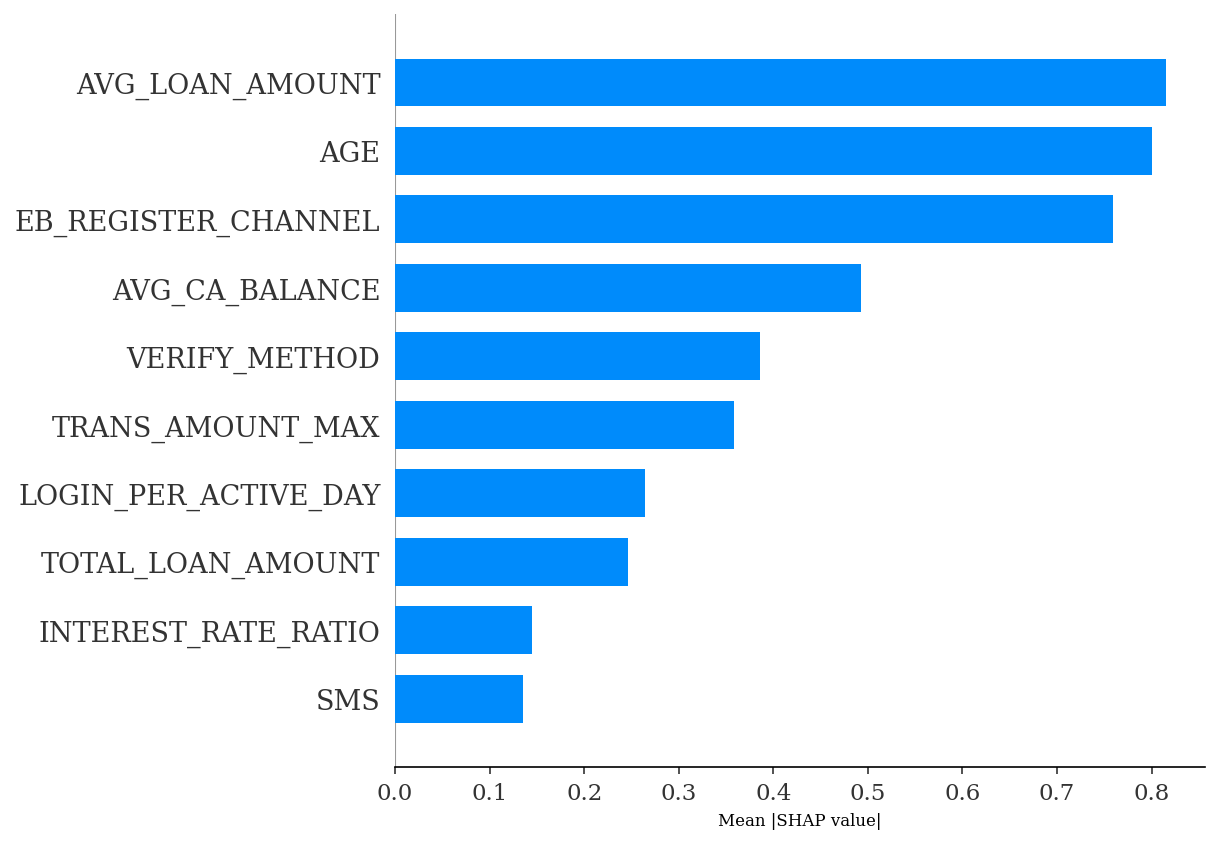

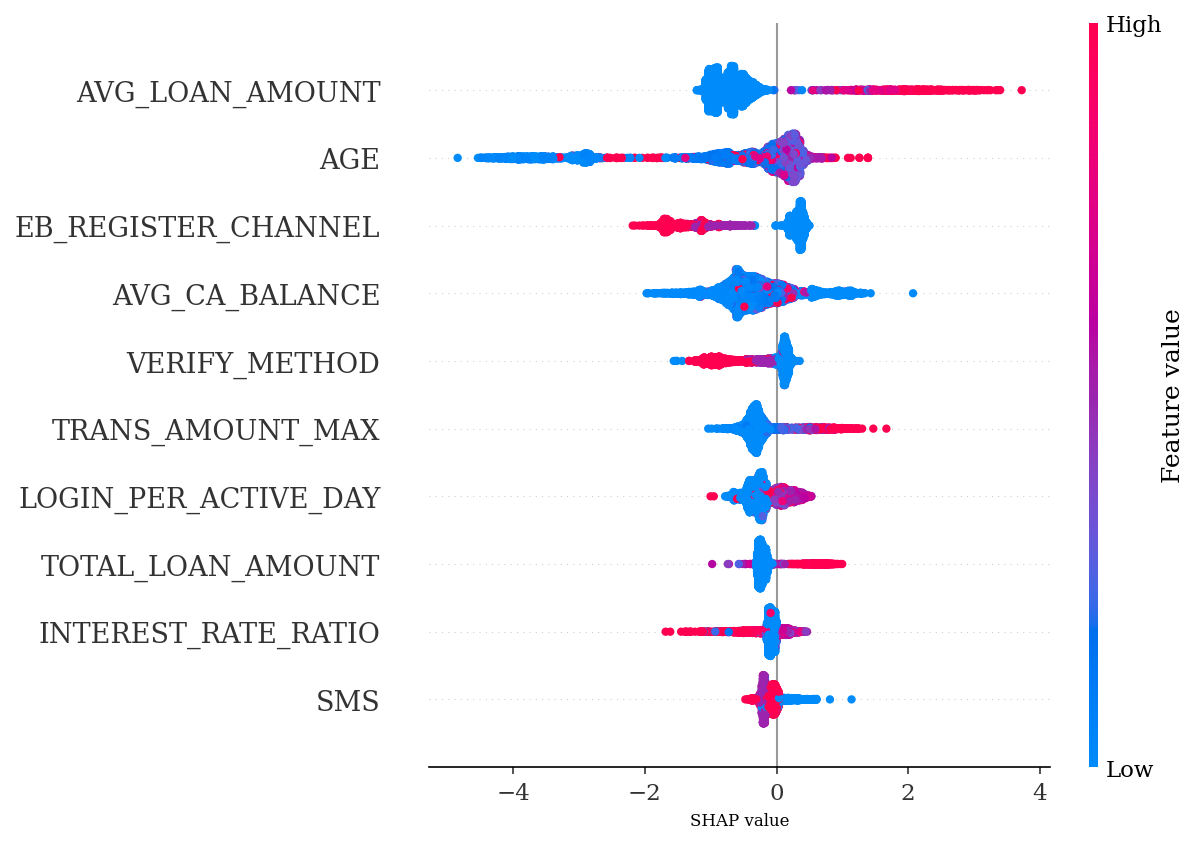

<Figure size 525x450 with 0 Axes>

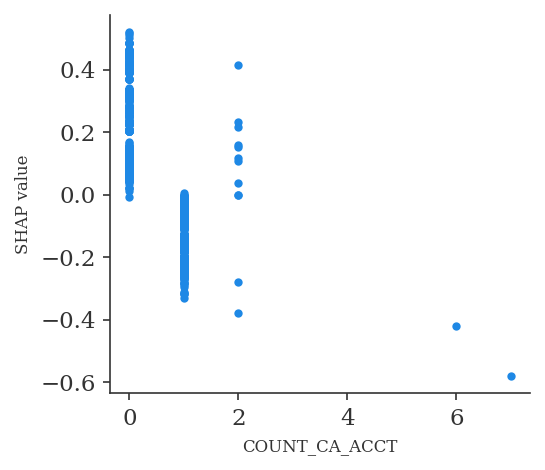


ETB XGBOOST + ROS COMPLETED

Final results:
                                                              0
MODEL                        XGBoost + RandomOverSampling (ROS)
N_CUSTOMERS                                               80100
N_TRAIN                                                   64080
N_TEST                                                    16020
N_FEATURES                                                   18
BASE_RATE                                              0.040974
CV_AUC_MEAN                                            0.909682
CV_AUC_STD                                             0.003163
TEST_AUC                                               0.904466
TEST_KS                                                 0.64957
TEST_RECALL                                            0.757622
TEST_PRECISION                                          0.20795
TEST_F1                                                 0.32633
TEST_ACCURACY                                           0.8

In [ ]:
# ============================================================
# ETB LANDMARK 90-DAY
# XGBOOST + RANDOM OVERSAMPLING
# CV + TEST METRICS + RANKING + SHAP
# GOOGLE COLAB — COPY AND RUN DIRECTLY
# ============================================================

# Chỉ chạy dòng dưới nếu thiếu thư viện:
# !pip install -q shap xgboost imbalanced-learn openpyxl psutil

import os
import gc
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIGURATION
# ============================================================

MYDRIVE_ROOT = "/content/gdrive2/MyDrive"

if not Path(MYDRIVE_ROOT).is_dir():
    raise RuntimeError(
        "Không truy cập được Google Drive tại:\n"
        f"{MYDRIVE_ROOT}\n\n"
        "Hãy mount Drive tại /content/gdrive2 trước khi chạy."
    )

INPUT_FILE = os.path.join(
    MYDRIVE_ROOT,
    "Fintect",
    "final_landmark_90d",
    "final_dataset_landmark_90d_no_auto_job.csv"
)

OUTPUT_DIR = os.path.join(
    MYDRIVE_ROOT,
    "Fintect",
    "landmark_90d_training_results",
    "full_metrics_shap"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_90D"

TEST_SIZE = 0.20
N_SPLITS = 5

SPLIT_RANDOM_STATE = 42
MODEL_RANDOM_STATE = 42

DECISION_THRESHOLD = 0.50

SHAP_SAMPLE_SIZE = 5000
MAX_SHAP_DISPLAY = 10

MODEL_NAME = "XGBoost + RandomOverSampling (ROS)"

print("=" * 80)
print("CONFIGURATION")
print("=" * 80)

print("Input file:")
print(INPUT_FILE)

print("\nInput exists:")
print(Path(INPUT_FILE).is_file())

print("\nOutput directory:")
print(OUTPUT_DIR)

if not Path(INPUT_FILE).is_file():
    raise FileNotFoundError(
        "Không tìm thấy file đầu vào:\n"
        f"{INPUT_FILE}"
    )


# ============================================================
# 2. EXCLUDED COLUMNS
# ============================================================

EXCLUDE_COLS = [
    ID_COL,
    TARGET_COL,

    "COUNT_CREDITCARD",
    "TOTAL_CARD",
    "RAW_TARGET",
    "TARGET",
    "TARGET_MONTH",

    "FIRST_CARD_MONTH",
    "FIRST_OBS_MONTH",
    "LAST_OBS_MONTH",

    "RELATIONSHIP_START_DATE",
    "LANDMARK_DATE",
    "FEATURE_CUTOFF_DATE",
    "CLIENT_CREATE_DATE",

    "HAS_90D_FOLLOWUP",
    "EARLY_CARD_90D",
    "TENURE_AT_CUTOFF",
    "TENURE_DAYS_AT_TARGET"
]


# ============================================================
# 3. IEEE FIGURE SETTINGS
# ============================================================

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "Times",
        "DejaVu Serif"
    ],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.0,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# ============================================================
# 4. HELPER FUNCTIONS
# ============================================================

def get_xgb_model():
    return XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        max_bin=256,
        random_state=MODEL_RANDOM_STATE,
        n_jobs=2
    )


def standardize_customer_id(series):
    return (
        series
        .astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )


def fit_preprocess(
    X_train_raw,
    X_valid_raw,
    categorical_columns
):
    X_train_work = X_train_raw.copy()
    X_valid_work = X_valid_raw.copy()

    encoder = None

    if categorical_columns:

        for col in categorical_columns:
            X_train_work[col] = (
                X_train_work[col]
                .astype("string")
                .fillna("UNKNOWN")
            )

            X_valid_work[col] = (
                X_valid_work[col]
                .astype("string")
                .fillna("UNKNOWN")
            )

        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1,
            dtype=np.float32
        )

        X_train_work[categorical_columns] = (
            encoder.fit_transform(
                X_train_work[categorical_columns]
            )
        )

        X_valid_work[categorical_columns] = (
            encoder.transform(
                X_valid_work[categorical_columns]
            )
        )

    for col in X_train_work.columns:
        X_train_work[col] = pd.to_numeric(
            X_train_work[col],
            errors="coerce"
        )

        X_valid_work[col] = pd.to_numeric(
            X_valid_work[col],
            errors="coerce"
        )

    imputer = SimpleImputer(strategy="median")

    X_train_processed = (
        imputer
        .fit_transform(X_train_work)
        .astype(np.float32)
    )

    X_valid_processed = (
        imputer
        .transform(X_valid_work)
        .astype(np.float32)
    )

    return (
        X_train_processed,
        X_valid_processed,
        imputer,
        encoder
    )


def calculate_ks(y_true, y_prob):
    fpr, tpr, _ = roc_curve(
        y_true,
        y_prob
    )

    return float(
        np.max(tpr - fpr)
    )


def calculate_ranking_metrics(
    y_true,
    y_prob,
    top_rates=(0.10, 0.20, 0.30)
):
    ranking = pd.DataFrame({
        "Y_TRUE": np.asarray(y_true),
        "Y_PROB": np.asarray(y_prob)
    })

    ranking = (
        ranking
        .sort_values(
            "Y_PROB",
            ascending=False
        )
        .reset_index(drop=True)
    )

    n = len(ranking)
    base_rate = float(ranking["Y_TRUE"].mean())
    total_positives = int(ranking["Y_TRUE"].sum())

    rows = []

    for rate in top_rates:
        k = max(
            1,
            int(np.ceil(n * rate))
        )

        top_group = ranking.iloc[:k]

        precision_at_k = float(
            top_group["Y_TRUE"].mean()
        )

        captured = int(
            top_group["Y_TRUE"].sum()
        )

        lift = (
            precision_at_k / base_rate
            if base_rate > 0
            else np.nan
        )

        capture_rate = (
            captured / total_positives
            if total_positives > 0
            else np.nan
        )

        rows.append({
            "TOP_K": f"Top {int(rate * 100)}%",
            "TOP_RATE": rate,
            "CUSTOMERS": k,
            "PRECISION": precision_at_k,
            "LIFT": lift,
            "CAPTURED_POSITIVES": captured,
            "CAPTURE_RATE": capture_rate
        })

    return pd.DataFrame(rows)


def create_decile_table(
    y_true,
    y_prob
):
    ranking = pd.DataFrame({
        "Y_TRUE": np.asarray(y_true),
        "Y_PROB": np.asarray(y_prob)
    })

    ranking = (
        ranking
        .sort_values(
            "Y_PROB",
            ascending=False
        )
        .reset_index(drop=True)
    )

    ranking["DECILE"] = pd.qcut(
        np.arange(len(ranking)),
        q=10,
        labels=[
            f"D{i}"
            for i in range(1, 11)
        ]
    )

    result = (
        ranking
        .groupby(
            "DECILE",
            observed=False
        )
        .agg(
            CUSTOMERS=("Y_TRUE", "count"),
            POSITIVES=("Y_TRUE", "sum"),
            ADOPTION_RATE=("Y_TRUE", "mean"),
            AVG_PRED_PROB=("Y_PROB", "mean")
        )
        .reset_index()
    )

    result["LIFT"] = (
        result["ADOPTION_RATE"]
        / ranking["Y_TRUE"].mean()
    )

    return result


# ============================================================
# 5. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

if ID_COL not in df.columns:
    raise ValueError(
        f"Không có cột {ID_COL}."
    )

if TARGET_COL not in df.columns:
    raise ValueError(
        f"Không có cột {TARGET_COL}."
    )

df[ID_COL] = standardize_customer_id(
    df[ID_COL]
)

df[TARGET_COL] = pd.to_numeric(
    df[TARGET_COL],
    errors="coerce"
)

df = df.dropna(
    subset=[
        ID_COL,
        TARGET_COL
    ]
).copy()

df[TARGET_COL] = (
    df[TARGET_COL]
    .astype(np.int8)
)

if not df[TARGET_COL].isin([0, 1]).all():
    raise ValueError(
        "TARGET_90D phải chỉ gồm 0 và 1."
    )

duplicate_count = int(
    df[ID_COL]
    .duplicated()
    .sum()
)

if duplicate_count > 0:
    raise ValueError(
        f"Có {duplicate_count:,} khách hàng bị trùng."
    )

df = df.replace(
    [
        "",
        " ",
        "NA",
        "N/A",
        "na",
        "null",
        "NULL",
        "None",
        "none"
    ],
    np.nan
)

df = (
    df
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("DATASET")
print("=" * 80)

print("Shape:", df.shape)

print("\nTarget distribution:")
print(
    df[TARGET_COL]
    .value_counts()
    .sort_index()
)

print(
    "\nPositive rate:",
    f"{df[TARGET_COL].mean() * 100:.4f}%"
)


# ============================================================
# 6. PREPARE FEATURES
# ============================================================

feature_cols = [
    col
    for col in df.columns
    if col not in EXCLUDE_COLS
]

X = df[feature_cols].copy()
y = df[TARGET_COL].copy()
customer_ids = df[ID_COL].copy()

for col in X.columns:

    is_text = (
        pd.api.types.is_object_dtype(X[col])
        or pd.api.types.is_string_dtype(X[col])
        or isinstance(
            X[col].dtype,
            pd.CategoricalDtype
        )
    )

    if is_text:

        converted = pd.to_numeric(
            X[col],
            errors="coerce"
        )

        original_non_null = int(
            X[col].notna().sum()
        )

        converted_non_null = int(
            converted.notna().sum()
        )

        numeric_ratio = (
            converted_non_null / original_non_null
            if original_non_null > 0
            else 0
        )

        if numeric_ratio >= 0.80:
            X[col] = converted
        else:
            X[col] = X[col].astype("string")

cat_cols = (
    X.select_dtypes(
        include=[
            "object",
            "string",
            "category"
        ]
    )
    .columns
    .tolist()
)

print("\nNumber of features:", len(feature_cols))

for i, feature in enumerate(
    feature_cols,
    start=1
):
    print(f"{i:02d}. {feature}")

print("\nCategorical columns:")
print(cat_cols)


# ============================================================
# 7. TRAIN–TEST SPLIT
# ============================================================

indices = np.arange(len(df))

train_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=SPLIT_RANDOM_STATE
)

X_train = (
    X.iloc[train_idx]
    .reset_index(drop=True)
)

X_test = (
    X.iloc[test_idx]
    .reset_index(drop=True)
)

y_train = (
    y.iloc[train_idx]
    .reset_index(drop=True)
)

y_test = (
    y.iloc[test_idx]
    .reset_index(drop=True)
)

test_ids = (
    customer_ids
    .iloc[test_idx]
    .reset_index(drop=True)
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


# ============================================================
# 8. FIVE-FOLD CROSS-VALIDATION
# ============================================================

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=MODEL_RANDOM_STATE
)

cv_rows = []

for fold, (
    fold_train_idx,
    fold_valid_idx
) in enumerate(
    skf.split(
        X_train,
        y_train
    ),
    start=1
):

    print(
        f"\nRunning fold {fold}/{N_SPLITS}..."
    )

    X_fold_train = X_train.iloc[
        fold_train_idx
    ]

    X_fold_valid = X_train.iloc[
        fold_valid_idx
    ]

    y_fold_train = y_train.iloc[
        fold_train_idx
    ]

    y_fold_valid = y_train.iloc[
        fold_valid_idx
    ]

    (
        X_fold_train_prep,
        X_fold_valid_prep,
        _,
        _
    ) = fit_preprocess(
        X_fold_train,
        X_fold_valid,
        cat_cols
    )

    ros = RandomOverSampler(
        random_state=MODEL_RANDOM_STATE
    )

    X_fold_ros, y_fold_ros = ros.fit_resample(
        X_fold_train_prep,
        y_fold_train.to_numpy()
    )

    model = get_xgb_model()

    model.fit(
        X_fold_ros,
        y_fold_ros
    )

    y_valid_prob = (
        model
        .predict_proba(
            X_fold_valid_prep
        )[:, 1]
    )

    y_valid_pred = (
        y_valid_prob
        >= DECISION_THRESHOLD
    ).astype(np.int8)

    fold_result = {
        "FOLD": fold,
        "AUC": roc_auc_score(
            y_fold_valid,
            y_valid_prob
        ),
        "KS": calculate_ks(
            y_fold_valid,
            y_valid_prob
        ),
        "RECALL": recall_score(
            y_fold_valid,
            y_valid_pred,
            zero_division=0
        ),
        "PRECISION": precision_score(
            y_fold_valid,
            y_valid_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_fold_valid,
            y_valid_pred,
            zero_division=0
        ),
        "ACCURACY": accuracy_score(
            y_fold_valid,
            y_valid_pred
        ),
        "BRIER": brier_score_loss(
            y_fold_valid,
            y_valid_prob
        )
    }

    cv_rows.append(fold_result)

    print(
        f"AUC={fold_result['AUC']:.4f} | "
        f"KS={fold_result['KS']:.4f} | "
        f"F1={fold_result['F1']:.4f}"
    )

    del model
    del ros
    del X_fold_train_prep
    del X_fold_valid_prep
    del X_fold_ros
    del y_fold_ros

    gc.collect()

cv_results = pd.DataFrame(cv_rows)

cv_summary = pd.DataFrame([
    {
        "METRIC": metric,
        "MEAN": cv_results[metric].mean(),
        "STD": cv_results[metric].std(ddof=1),
        "MEAN_PLUS_MINUS_SD": (
            f"{cv_results[metric].mean():.4f} ± "
            f"{cv_results[metric].std(ddof=1):.4f}"
        )
    }
    for metric in [
        "AUC",
        "KS",
        "RECALL",
        "PRECISION",
        "F1",
        "ACCURACY",
        "BRIER"
    ]
])


# ============================================================
# 9. TRAIN FINAL MODEL
# ============================================================

(
    X_train_prep,
    X_test_prep,
    final_imputer,
    final_encoder
) = fit_preprocess(
    X_train,
    X_test,
    cat_cols
)

ros = RandomOverSampler(
    random_state=MODEL_RANDOM_STATE
)

X_train_ros, y_train_ros = ros.fit_resample(
    X_train_prep,
    y_train.to_numpy()
)

final_model = get_xgb_model()

final_model.fit(
    X_train_ros,
    y_train_ros
)


# ============================================================
# 10. TEST METRICS
# ============================================================

y_test_prob = (
    final_model
    .predict_proba(
        X_test_prep
    )[:, 1]
)

y_test_pred = (
    y_test_prob
    >= DECISION_THRESHOLD
).astype(np.int8)

test_auc = roc_auc_score(
    y_test,
    y_test_prob
)

test_ks = calculate_ks(
    y_test,
    y_test_prob
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_brier = brier_score_loss(
    y_test,
    y_test_prob
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[0, 1]
).ravel()

print("\n" + "=" * 80)
print("TEST RESULTS")
print("=" * 80)

print(f"AUC       : {test_auc:.6f}")
print(f"KS        : {test_ks:.6f}")
print(f"Recall    : {test_recall:.6f}")
print(f"Precision : {test_precision:.6f}")
print(f"F1        : {test_f1:.6f}")
print(f"Accuracy  : {test_accuracy:.6f}")
print(f"Brier     : {test_brier:.6f}")

print("\nConfusion matrix:")
print(
    np.array([
        [tn, fp],
        [fn, tp]
    ])
)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 11. RANKING METRICS
# ============================================================

ranking_results = calculate_ranking_metrics(
    y_test,
    y_test_prob
)

decile_table = create_decile_table(
    y_test,
    y_test_prob
)

print("\nRanking metrics:")
print(
    ranking_results
    .to_string(index=False)
)

predictions = pd.DataFrame({
    ID_COL: test_ids.to_numpy(),
    "Y_TRUE": y_test.to_numpy(),
    "Y_PROB": np.asarray(y_test_prob),
    "Y_PRED": np.asarray(y_test_pred)
})


# ============================================================
# 12. SHAP
# ============================================================

sample_size = min(
    SHAP_SAMPLE_SIZE,
    len(X_test_prep)
)

rng = np.random.default_rng(
    MODEL_RANDOM_STATE
)

shap_indices = rng.choice(
    len(X_test_prep),
    size=sample_size,
    replace=False
)

X_shap = pd.DataFrame(
    X_test_prep[shap_indices],
    columns=feature_cols
)

print("\nComputing SHAP values...")

explainer = shap.TreeExplainer(
    final_model
)

shap_values_raw = explainer.shap_values(
    X_shap
)

if isinstance(shap_values_raw, list):
    shap_values = np.asarray(
        shap_values_raw[-1]
    )
else:
    shap_values = np.asarray(
        shap_values_raw
    )

if shap_values.ndim == 3:
    shap_values = shap_values[:, :, -1]

if shap_values.shape != X_shap.shape:
    raise ValueError(
        "SHAP shape không khớp dữ liệu:\n"
        f"SHAP={shap_values.shape}\n"
        f"X_SHAP={X_shap.shape}"
    )

shap_importance = pd.DataFrame({
    "FEATURE": feature_cols,
    "MEAN_ABS_SHAP": np.abs(
        shap_values
    ).mean(axis=0),
    "MEAN_SIGNED_SHAP": shap_values.mean(
        axis=0
    )
})

shap_importance = (
    shap_importance
    .sort_values(
        "MEAN_ABS_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

shap_importance.insert(
    0,
    "RANK",
    np.arange(
        1,
        len(shap_importance) + 1
    )
)

top5_shap = shap_importance.head(5).copy()

count_ca_result = shap_importance.loc[
    shap_importance["FEATURE"]
    .astype(str)
    .str.upper()
    == "COUNT_CA_ACCT"
]

if not count_ca_result.empty:
    count_ca_rank = int(
        count_ca_result.iloc[0]["RANK"]
    )

    count_ca_mean_abs = float(
        count_ca_result.iloc[0][
            "MEAN_ABS_SHAP"
        ]
    )
else:
    count_ca_rank = None
    count_ca_mean_abs = None

print("\nTop 10 SHAP features:")
print(
    shap_importance
    .head(10)
    .to_string(index=False)
)

print("\nCOUNT_CA_ACCT SHAP rank:")
print(count_ca_rank)


# ============================================================
# 13. SHAP BAR PLOT
# ============================================================

plt.figure(
    figsize=(3.5, 3.0)
)

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=MAX_SHAP_DISPLAY,
    show=False
)

plt.xlabel(
    "Mean |SHAP value|",
    fontsize=8
)

plt.tight_layout(pad=0.3)

bar_png = os.path.join(
    OUTPUT_DIR,
    "Fig_ETB_SHAP_Bar_600dpi.png"
)

plt.savefig(
    bar_png,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "Fig_ETB_SHAP_Bar.pdf"
    ),
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()
plt.close()


# ============================================================
# 14. SHAP BEESWARM
# ============================================================

plt.figure(
    figsize=(3.5, 3.25)
)

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=MAX_SHAP_DISPLAY,
    show=False
)

plt.xlabel(
    "SHAP value",
    fontsize=8
)

plt.tight_layout(pad=0.3)

beeswarm_png = os.path.join(
    OUTPUT_DIR,
    "Fig_ETB_SHAP_Beeswarm_600dpi.png"
)

plt.savefig(
    beeswarm_png,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "Fig_ETB_SHAP_Beeswarm.pdf"
    ),
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()
plt.close()


# ============================================================
# 15. COUNT_CA_ACCT DEPENDENCE PLOT
# ============================================================

count_ca_png = None

if "COUNT_CA_ACCT" in feature_cols:

    plt.figure(
        figsize=(3.5, 3.0)
    )

    shap.dependence_plot(
        "COUNT_CA_ACCT",
        shap_values,
        X_shap,
        interaction_index=None,
        show=False
    )

    plt.gcf().set_size_inches(
        3.5,
        3.0
    )

    plt.xlabel(
        "COUNT_CA_ACCT",
        fontsize=8
    )

    plt.ylabel(
        "SHAP value",
        fontsize=8
    )

    plt.tight_layout(pad=0.3)

    count_ca_png = os.path.join(
        OUTPUT_DIR,
        "Fig_ETB_COUNT_CA_ACCT_Dependence_600dpi.png"
    )

    plt.savefig(
        count_ca_png,
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.02
    )

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "Fig_ETB_COUNT_CA_ACCT_Dependence.pdf"
        ),
        bbox_inches="tight",
        pad_inches=0.02
    )

    plt.show()
    plt.close()


# ============================================================
# 16. FINAL RESULT TABLE
# ============================================================

top10 = ranking_results.loc[
    ranking_results["TOP_RATE"] == 0.10
].iloc[0]

top20 = ranking_results.loc[
    ranking_results["TOP_RATE"] == 0.20
].iloc[0]

top30 = ranking_results.loc[
    ranking_results["TOP_RATE"] == 0.30
].iloc[0]

final_results = pd.DataFrame([{
    "MODEL": MODEL_NAME,

    "N_CUSTOMERS": len(df),
    "N_TRAIN": len(X_train),
    "N_TEST": len(X_test),
    "N_FEATURES": len(feature_cols),

    "BASE_RATE": float(y.mean()),

    "CV_AUC_MEAN": float(
        cv_results["AUC"].mean()
    ),

    "CV_AUC_STD": float(
        cv_results["AUC"].std(ddof=1)
    ),

    "TEST_AUC": test_auc,
    "TEST_KS": test_ks,
    "TEST_RECALL": test_recall,
    "TEST_PRECISION": test_precision,
    "TEST_F1": test_f1,
    "TEST_ACCURACY": test_accuracy,
    "TEST_BRIER": test_brier,

    "TN": int(tn),
    "FP": int(fp),
    "FN": int(fn),
    "TP": int(tp),

    "PRECISION_AT_10": float(
        top10["PRECISION"]
    ),

    "LIFT_AT_10": float(
        top10["LIFT"]
    ),

    "CAPTURE_RATE_AT_10": float(
        top10["CAPTURE_RATE"]
    ),

    "PRECISION_AT_20": float(
        top20["PRECISION"]
    ),

    "LIFT_AT_20": float(
        top20["LIFT"]
    ),

    "CAPTURE_RATE_AT_20": float(
        top20["CAPTURE_RATE"]
    ),

    "PRECISION_AT_30": float(
        top30["PRECISION"]
    ),

    "LIFT_AT_30": float(
        top30["LIFT"]
    ),

    "CAPTURE_RATE_AT_30": float(
        top30["CAPTURE_RATE"]
    ),

    "TOP_SHAP_FEATURE": str(
        top5_shap.iloc[0]["FEATURE"]
    ),

    "COUNT_CA_ACCT_SHAP_RANK": (
        count_ca_rank
    ),

    "COUNT_CA_ACCT_MEAN_ABS_SHAP": (
        count_ca_mean_abs
    )
}])


# ============================================================
# 17. SAVE OUTPUTS
# ============================================================

final_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "etb_final_results.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

cv_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "etb_cross_validation_results.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

cv_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "etb_cv_mean_sd.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

ranking_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "etb_ranking_metrics.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

decile_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "etb_decile_table.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

predictions.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "etb_test_predictions.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

shap_importance.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "etb_shap_global_importance.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

top5_shap.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "etb_shap_top5.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

excel_file = os.path.join(
    OUTPUT_DIR,
    "etb_xgboost_ros_metrics_shap.xlsx"
)

with pd.ExcelWriter(excel_file) as writer:

    final_results.to_excel(
        writer,
        sheet_name="Final results",
        index=False
    )

    cv_results.to_excel(
        writer,
        sheet_name="Cross validation",
        index=False
    )

    cv_summary.to_excel(
        writer,
        sheet_name="CV mean SD",
        index=False
    )

    ranking_results.to_excel(
        writer,
        sheet_name="Ranking",
        index=False
    )

    decile_table.to_excel(
        writer,
        sheet_name="Deciles",
        index=False
    )

    predictions.to_excel(
        writer,
        sheet_name="Test predictions",
        index=False
    )

    shap_importance.to_excel(
        writer,
        sheet_name="SHAP importance",
        index=False
    )

    top5_shap.to_excel(
        writer,
        sheet_name="SHAP top 5",
        index=False
    )


# ============================================================
# 18. FINAL REPORT
# ============================================================

print("\n" + "=" * 90)
print("ETB XGBOOST + ROS COMPLETED")
print("=" * 90)

print("\nFinal results:")
print(final_results.T)

print("\nCV mean ± SD:")
print(
    cv_summary[
        [
            "METRIC",
            "MEAN_PLUS_MINUS_SD"
        ]
    ]
)

print("\nTop five SHAP features:")
print(
    top5_shap[
        [
            "RANK",
            "FEATURE",
            "MEAN_ABS_SHAP"
        ]
    ]
    .to_string(index=False)
)

print("\nCOUNT_CA_ACCT SHAP rank:")
print(count_ca_rank)

print("\nSaved Excel:")
print(excel_file)

print("\nSaved directory:")
print(OUTPUT_DIR)

SHAP ANALYSIS
SHAP sample size: 5000
Number of features: 18

Computing SHAP values...
SHAP values shape: (5000, 18)

Top 10 SHAP features:
 RANK              FEATURE  MEAN_ABS_SHAP  MEAN_SIGNED_SHAP
    1      AVG_LOAN_AMOUNT       0.815645         -0.516993
    2                  AGE       0.800824         -0.588553
    3  EB_REGISTER_CHANNEL       0.758705         -0.374801
    4       AVG_CA_BALANCE       0.492146         -0.310412
    5        VERIFY_METHOD       0.385890         -0.253795
    6     TRANS_AMOUNT_MAX       0.358604         -0.199051
    7 LOGIN_PER_ACTIVE_DAY       0.264315         -0.164971
    8    TOTAL_LOAN_AMOUNT       0.246246         -0.165118
    9  INTEREST_RATE_RATIO       0.144515         -0.092077
   10                  SMS       0.135130         -0.088506

COUNT_CA_ACCT:
Rank: 12
Mean |SHAP|: 0.094078


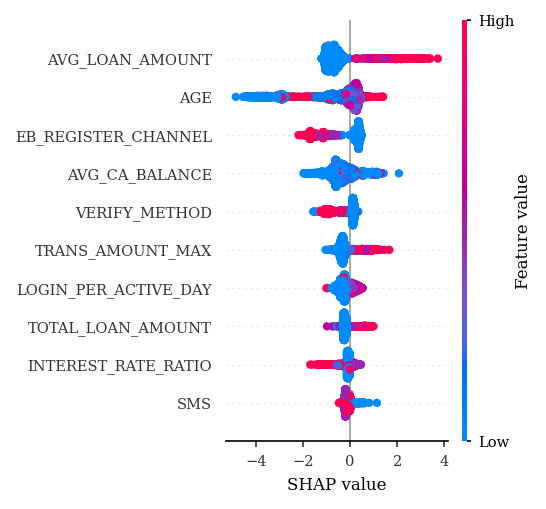

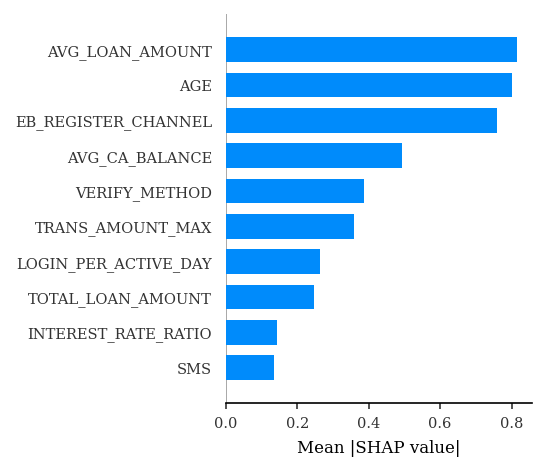

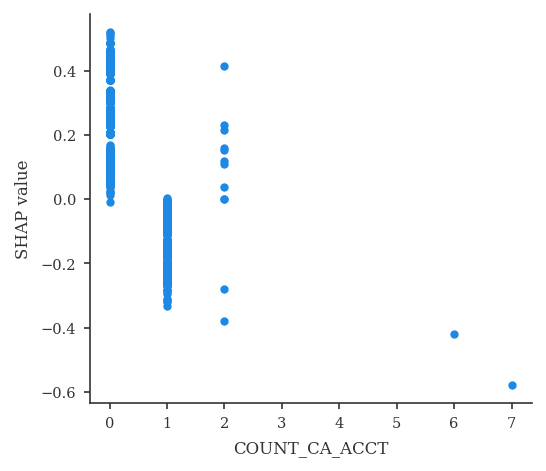


SHAP ANALYSIS COMPLETED

Top five features:
 RANK             FEATURE  MEAN_ABS_SHAP
    1     AVG_LOAN_AMOUNT       0.815645
    2                 AGE       0.800824
    3 EB_REGISTER_CHANNEL       0.758705
    4      AVG_CA_BALANCE       0.492146
    5       VERIFY_METHOD       0.385890

COUNT_CA_ACCT rank:
12

Main paper figure:
/content/gdrive2/MyDrive/Fintect/landmark_90d_training_results/full_metrics_shap/Fig_FLDC_SHAP_Beeswarm_600dpi.png

Vector PDF:
/content/gdrive2/MyDrive/Fintect/landmark_90d_training_results/full_metrics_shap/Fig_FLDC_SHAP_Beeswarm.pdf

Output directory:
/content/gdrive2/MyDrive/Fintect/landmark_90d_training_results/full_metrics_shap


6588

In [ ]:
# ============================================================
# SHAP ANALYSIS — IEEE SINGLE-COLUMN FIGURE
#
# Required variables already available:
#   final_model
#   X_test_prep
#   feature_cols
#
# Outputs:
#   - etb_shap_global_importance.csv
#   - etb_shap_top5.csv
#   - Fig_FLDC_SHAP_Beeswarm_600dpi.png
#   - Fig_FLDC_SHAP_Beeswarm.pdf
#   - Fig_FLDC_SHAP_Bar_600dpi.png
#   - Fig_FLDC_SHAP_Bar.pdf
# ============================================================

import os
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import shap

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIGURATION
# ============================================================

OUTPUT_DIR = (
    "/content/gdrive2/MyDrive/Fintect/"
    "landmark_90d_training_results/full_metrics_shap"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

SHAP_SAMPLE_SIZE = 5000
MAX_DISPLAY = 10
RANDOM_STATE = 42


# ============================================================
# 2. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "final_model",
    "X_test_prep",
    "feature_cols"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Thiếu các biến cần thiết:\n"
        f"{missing_variables}\n\n"
        "Hãy chạy phần huấn luyện final model trước."
    )

if len(feature_cols) != X_test_prep.shape[1]:
    raise ValueError(
        "Số lượng feature không khớp với X_test_prep.\n"
        f"len(feature_cols) = {len(feature_cols)}\n"
        f"X_test_prep.shape[1] = {X_test_prep.shape[1]}"
    )


# ============================================================
# 3. IEEE FIGURE SETTINGS
# ============================================================

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "Times",
        "DejaVu Serif"
    ],

    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,

    "axes.linewidth": 0.8,
    "lines.linewidth": 0.8,

    "figure.dpi": 150,
    "savefig.dpi": 600,

    # Preserve editable text in PDF.
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# ============================================================
# 4. SELECT TEST SAMPLE FOR SHAP
#
# SHAP is calculated on the original test set,
# not on the oversampled training set.
# ============================================================

sample_size = min(
    SHAP_SAMPLE_SIZE,
    len(X_test_prep)
)

rng = np.random.default_rng(
    RANDOM_STATE
)

shap_indices = rng.choice(
    len(X_test_prep),
    size=sample_size,
    replace=False
)

X_shap_array = np.asarray(
    X_test_prep[shap_indices],
    dtype=np.float32
)

X_shap = pd.DataFrame(
    X_shap_array,
    columns=feature_cols
)

print("=" * 75)
print("SHAP ANALYSIS")
print("=" * 75)

print(
    "SHAP sample size:",
    len(X_shap)
)

print(
    "Number of features:",
    len(feature_cols)
)


# ============================================================
# 5. COMPUTE SHAP VALUES
# ============================================================

print("\nComputing SHAP values...")

explainer = shap.TreeExplainer(
    final_model
)

shap_values_raw = explainer.shap_values(
    X_shap
)

# Compatibility across SHAP versions.
if isinstance(
    shap_values_raw,
    list
):

    if len(shap_values_raw) == 2:
        shap_values = np.asarray(
            shap_values_raw[1]
        )
    else:
        shap_values = np.asarray(
            shap_values_raw[-1]
        )

else:
    shap_values = np.asarray(
        shap_values_raw
    )

# Some SHAP versions return:
# n_samples × n_features × n_classes
if shap_values.ndim == 3:

    if shap_values.shape[-1] == 2:
        shap_values = shap_values[
            :,
            :,
            1
        ]
    else:
        shap_values = shap_values[
            :,
            :,
            0
        ]

if shap_values.shape != X_shap.shape:
    raise ValueError(
        "Kích thước SHAP không khớp dữ liệu.\n"
        f"SHAP shape: {shap_values.shape}\n"
        f"X_shap shape: {X_shap.shape}"
    )

print(
    "SHAP values shape:",
    shap_values.shape
)


# ============================================================
# 6. GLOBAL SHAP IMPORTANCE
# ============================================================

mean_abs_shap = (
    np.abs(
        shap_values
    )
    .mean(axis=0)
)

mean_signed_shap = (
    shap_values
    .mean(axis=0)
)

shap_importance = pd.DataFrame({
    "FEATURE": feature_cols,
    "MEAN_ABS_SHAP": mean_abs_shap,
    "MEAN_SIGNED_SHAP": mean_signed_shap
})

shap_importance = (
    shap_importance
    .sort_values(
        "MEAN_ABS_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

shap_importance.insert(
    0,
    "RANK",
    np.arange(
        1,
        len(shap_importance) + 1
    )
)

top5_shap = (
    shap_importance
    .head(5)
    .copy()
)

shap_importance.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "etb_shap_global_importance.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

top5_shap.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "etb_shap_top5.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

print("\nTop 10 SHAP features:")

print(
    shap_importance
    .head(10)
    .to_string(index=False)
)


# ============================================================
# 7. COUNT_CA_ACCT RANK
# ============================================================

count_ca_result = shap_importance.loc[
    shap_importance["FEATURE"]
    .astype(str)
    .str.upper()
    == "COUNT_CA_ACCT"
]

if not count_ca_result.empty:

    count_ca_rank = int(
        count_ca_result.iloc[0]["RANK"]
    )

    count_ca_mean_abs = float(
        count_ca_result.iloc[0][
            "MEAN_ABS_SHAP"
        ]
    )

    print("\nCOUNT_CA_ACCT:")

    print(
        "Rank:",
        count_ca_rank
    )

    print(
        "Mean |SHAP|:",
        f"{count_ca_mean_abs:.6f}"
    )

else:

    count_ca_rank = None
    count_ca_mean_abs = None

    print(
        "\nCOUNT_CA_ACCT không có "
        "trong feature set."
    )


# ============================================================
# 8. SHAP BEESWARM
# MAIN FIGURE RECOMMENDED FOR THE PAPER
#
# IEEE single-column width:
#   3.5 inches
# ============================================================

plt.close("all")

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=MAX_DISPLAY,
    show=False,
    plot_size=None
)

figure = plt.gcf()

figure.set_size_inches(
    3.5,
    3.25
)

axes = figure.axes

main_axis = axes[0]

main_axis.set_xlabel(
    "SHAP value",
    fontsize=8
)

main_axis.tick_params(
    axis="x",
    labelsize=7,
    width=0.8,
    length=3
)

main_axis.tick_params(
    axis="y",
    labelsize=7,
    width=0.8,
    length=3
)

for spine in main_axis.spines.values():
    spine.set_linewidth(0.8)

# SHAP creates an additional color-bar axis.
if len(axes) > 1:

    colorbar_axis = axes[-1]

    colorbar_axis.tick_params(
        labelsize=7,
        width=0.8,
        length=2
    )

    colorbar_axis.set_ylabel(
        "Feature value",
        fontsize=8
    )

# No title: IEEE figure caption provides the title.
plt.tight_layout(
    pad=0.25
)

beeswarm_png = os.path.join(
    OUTPUT_DIR,
    "Fig_FLDC_SHAP_Beeswarm_600dpi.png"
)

beeswarm_pdf = os.path.join(
    OUTPUT_DIR,
    "Fig_FLDC_SHAP_Beeswarm.pdf"
)

plt.savefig(
    beeswarm_png,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.savefig(
    beeswarm_pdf,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()
plt.close()


# ============================================================
# 9. SHAP BAR PLOT
# OPTIONAL — USE ONLY IF NEEDED
# ============================================================

plt.close("all")

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=MAX_DISPLAY,
    show=False,
    plot_size=None
)

figure = plt.gcf()

figure.set_size_inches(
    3.5,
    3.0
)

axis = figure.axes[0]

axis.set_xlabel(
    "Mean |SHAP value|",
    fontsize=8
)

axis.tick_params(
    axis="x",
    labelsize=7,
    width=0.8,
    length=3
)

axis.tick_params(
    axis="y",
    labelsize=7,
    width=0.8,
    length=3
)

for spine in axis.spines.values():
    spine.set_linewidth(0.8)

plt.tight_layout(
    pad=0.25
)

bar_png = os.path.join(
    OUTPUT_DIR,
    "Fig_FLDC_SHAP_Bar_600dpi.png"
)

bar_pdf = os.path.join(
    OUTPUT_DIR,
    "Fig_FLDC_SHAP_Bar.pdf"
)

plt.savefig(
    bar_png,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.savefig(
    bar_pdf,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()
plt.close()


# ============================================================
# 10. OPTIONAL COUNT_CA_ACCT DEPENDENCE PLOT
# ============================================================

count_ca_png = None
count_ca_pdf = None

if "COUNT_CA_ACCT" in feature_cols:

    plt.close("all")

    shap.dependence_plot(
        "COUNT_CA_ACCT",
        shap_values,
        X_shap,
        interaction_index=None,
        show=False
    )

    figure = plt.gcf()

    figure.set_size_inches(
        3.5,
        3.0
    )

    axis = figure.axes[0]

    axis.set_xlabel(
        "COUNT_CA_ACCT",
        fontsize=8
    )

    axis.set_ylabel(
        "SHAP value",
        fontsize=8
    )

    axis.tick_params(
        axis="x",
        labelsize=7,
        width=0.8,
        length=3
    )

    axis.tick_params(
        axis="y",
        labelsize=7,
        width=0.8,
        length=3
    )

    for spine in axis.spines.values():
        spine.set_linewidth(0.8)

    plt.tight_layout(
        pad=0.25
    )

    count_ca_png = os.path.join(
        OUTPUT_DIR,
        "Fig_FLDC_COUNT_CA_ACCT_Dependence_600dpi.png"
    )

    count_ca_pdf = os.path.join(
        OUTPUT_DIR,
        "Fig_FLDC_COUNT_CA_ACCT_Dependence.pdf"
    )

    plt.savefig(
        count_ca_png,
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.02
    )

    plt.savefig(
        count_ca_pdf,
        format="pdf",
        bbox_inches="tight",
        pad_inches=0.02
    )

    plt.show()
    plt.close()


# ============================================================
# 11. FINAL REPORT
# ============================================================

print("\n" + "=" * 75)
print("SHAP ANALYSIS COMPLETED")
print("=" * 75)

print("\nTop five features:")

print(
    top5_shap[
        [
            "RANK",
            "FEATURE",
            "MEAN_ABS_SHAP"
        ]
    ]
    .to_string(index=False)
)

print("\nCOUNT_CA_ACCT rank:")
print(count_ca_rank)

print("\nMain paper figure:")
print(beeswarm_png)

print("\nVector PDF:")
print(beeswarm_pdf)

print("\nOutput directory:")
print(OUTPUT_DIR)


# ============================================================
# 12. MEMORY CLEANUP
# ============================================================

del shap_values_raw
del shap_values
del explainer
del X_shap
del X_shap_array

gc.collect()